In [53]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML
HTML('''
<style>
div.input {display:none;}
</style>
''')

In [54]:
# read the original data
children = pd.read_csv('child24.csv')


In [55]:
# DEMOGRAPHICS

demographics = ["SEX_C", "RELTIVP_C", "RACEALLP_C"]

# MAIN OUTCOME
main_outcome = ["PHSTAT_C"]

# PSYCHOSOCIAL COVARIATES
psychosocial_covariates = ["ANXFREQ_C", "DEPFREQ_C", "SCHDYMSSTC_C"]

# SOCIAL DETERMINANTS OF HEALTH COVARIATES

# Income, Insurance

social_determinants = ["NOTCOV_C", "COVER_C", "FSNAP12M_C", "FWIC12M_C", "FLUNCH12M1_C"]

# Education
education = ["MAXPAREDUP_C"]

# Food Security

# FDSCAT34_C
food_security = ["FDSCAT3_C", "FDSCAT4_C"]

# Housing
housing = ["HOUTENURE_C"]

# Built Environment
built_environment = ["SIDEWALK_C", "PARKS_C", "TRAFFIC_C", "CRIME_C"]

# ELIGIBILITY
eligibility = ["AGEP_C", "CURFOOD_C"]

# Variables
variables = [
    *demographics,
    *main_outcome,
    *psychosocial_covariates,
    *social_determinants,
    *education,
    *food_security,
    *housing,
    *built_environment,
    *eligibility
]


child_data = children[variables]

In [56]:
# Limit the age range

children_with_age_range = child_data[
    child_data["AGEP_C"].between(5, 17)
]

# children_with_age_range

## Exploratory Data Analysis (EDA)   

### Sample Overview

- Total number of surveyed children
- The number of surveyed children in selected age range 5 to 17

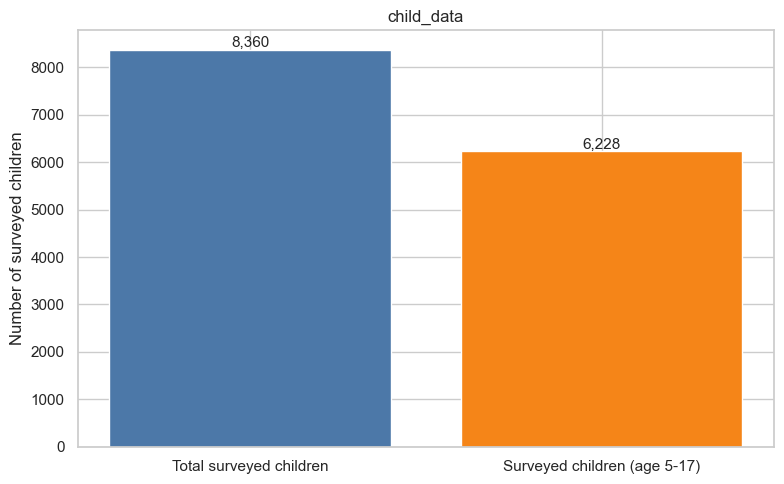

In [57]:
# Sample Overview

total_children = child_data.shape[0]
children_5_to_17 = children_with_age_range.shape[0]

sample_overview = pd.DataFrame({
    "Group": ["Total surveyed children", "Surveyed children (age 5-17)"],
    "Count": [total_children, children_5_to_17]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(sample_overview["Group"], sample_overview["Count"], color=["#4C78A8", "#F58518"])

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("child_data")
plt.ylabel("Number of surveyed children")
plt.xlabel("")
plt.tight_layout()
plt.show()


### Demographics

- The number of children by age
- The number of children by sex
- The number of children by race/ethnicity

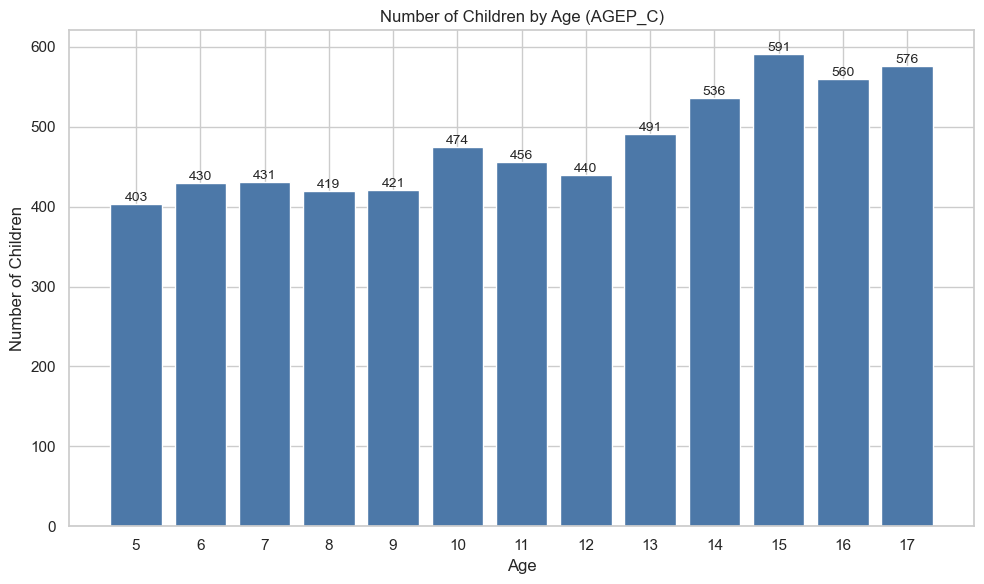

In [58]:
# Demographics - Bar chart 1: Number of children by age (5 to 17)

age_series = pd.to_numeric(child_data["AGEP_C"], errors="coerce")
age_5_to_17 = age_series[age_series.between(5, 17)]

# Keep all ages from 5 to 17 on the x-axis, filling missing ages with 0
age_counts = age_5_to_17.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts above each bar
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Age (AGEP_C)")
plt.xlabel("Age")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


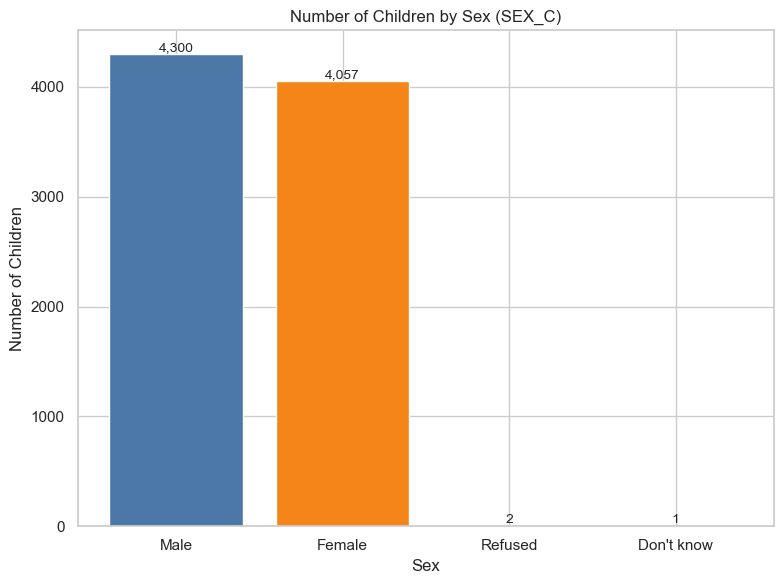

In [59]:
#| hide_input
# Demographics - Bar chart 2: Number of children by sex

sex_labels_map = {
    1: "Male",
    2: "Female",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

sex_series = pd.to_numeric(child_data["SEX_C"], errors="coerce")
sex_counts = sex_series.value_counts().sort_index()
sex_labels = [sex_labels_map.get(int(code), f"Code {int(code)}") for code in sex_counts.index]

# Use a different color for each bar
bar_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"][:len(sex_counts)]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children by Sex (SEX_C)")
plt.xlabel("Sex")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()


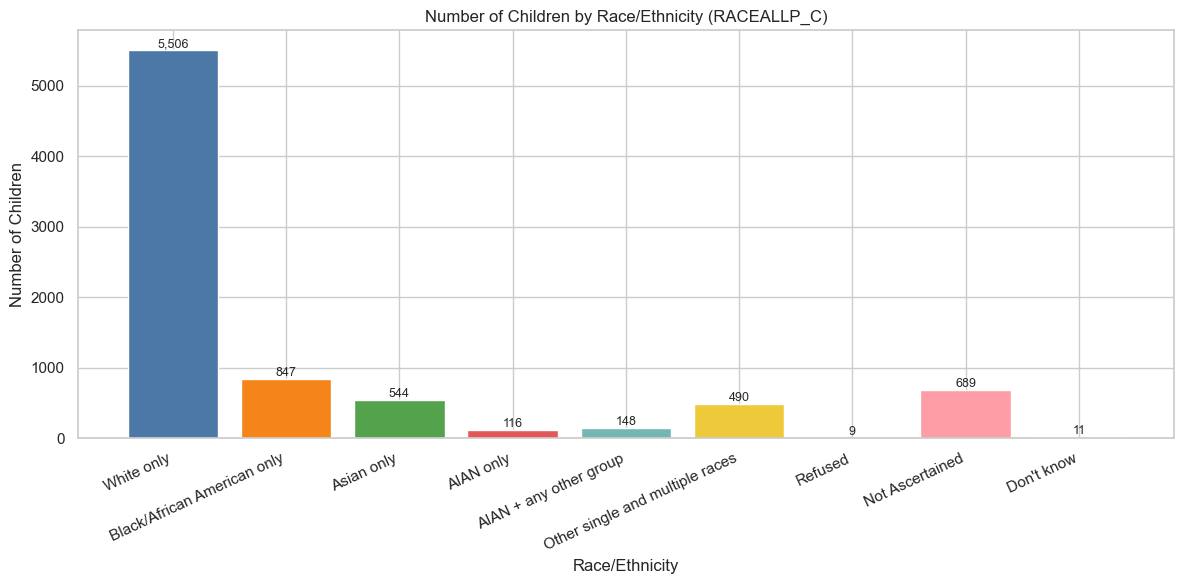

In [60]:
# Demographics - Bar chart 3: Number of children by race/ethnicity

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

race_series = pd.to_numeric(child_data["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

# Use a different color for each bar
bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts above each bar
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children by Race/Ethnicity (RACEALLP_C)")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Children")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Food Allergy

- The number of children with current food allergy (CURFOOD_C)
- Percentage of children with current food allergy

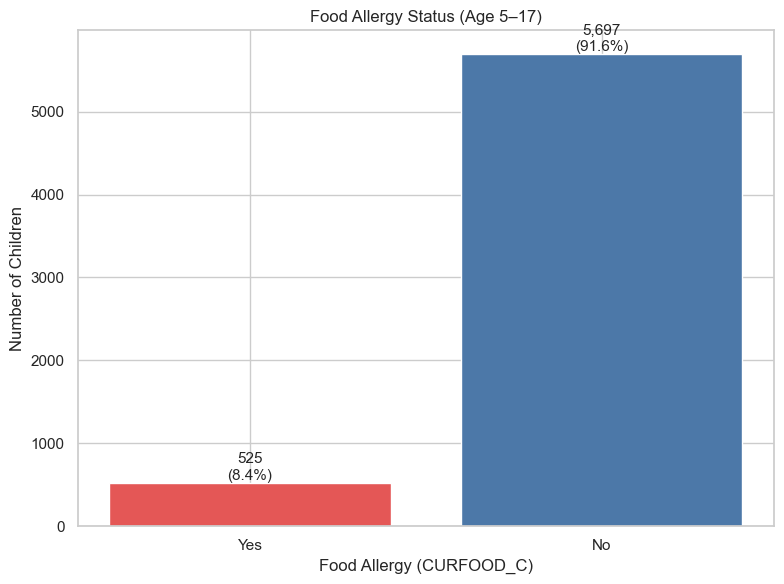

In [61]:
food_series = pd.to_numeric(
    children_with_age_range["CURFOOD_C"], errors="coerce"
)
food_series = food_series[food_series.isin([1, 2])]

# count
counts = food_series.value_counts().reindex([1, 2], fill_value=0)

# percentage
percentages = (counts / counts.sum()) * 100

# labels & colors
labels = ["Yes", "No"]
colors = ["#E45756", "#4C78A8"]

# graph
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts.values, color=colors)

# count + percentage
for bar, count, pct in zip(bars, counts.values, percentages.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Food Allergy Status (Age 5–17)")
plt.xlabel("Food Allergy (CURFOOD_C)")
plt.ylabel("Number of Children")
plt.tight_layout()
plt.show()

- The number of children having food allergy by sex
- The number of children having food allergy by age
- The number of children having food allergy by race/ethnicity

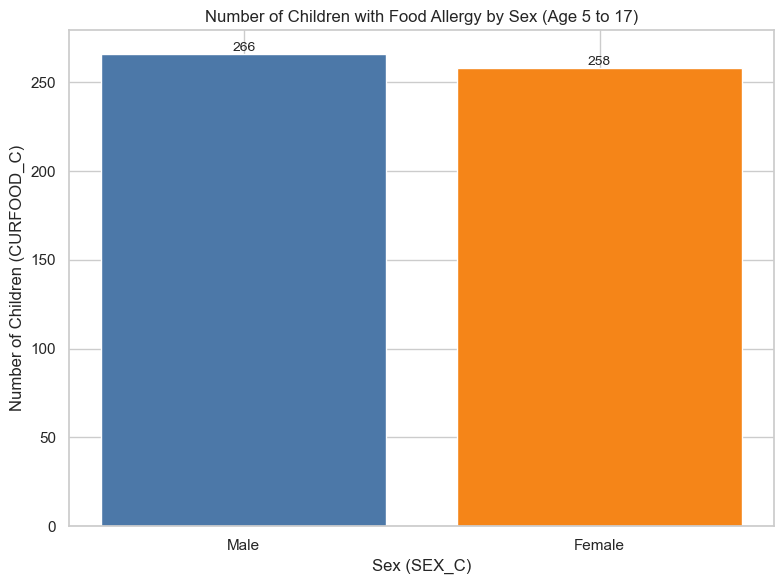

In [62]:
# The number of children having food allergy by sex (Male/Female only, age 5-17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep only Male(1), Female(2)
sex_series = pd.to_numeric(allergy_yes["SEX_C"], errors="coerce")
sex_series = sex_series[sex_series.isin([1, 2])]

# Fixed order: Male, Female
sex_counts = sex_series.value_counts().reindex([1, 2], fill_value=0)
sex_labels = ["Male", "Female"]
bar_colors = ["#4C78A8", "#F58518"]

plt.figure(figsize=(8, 6))
bars = plt.bar(sex_labels, sex_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, sex_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Sex (Age 5 to 17)")
plt.xlabel("Sex (SEX_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()


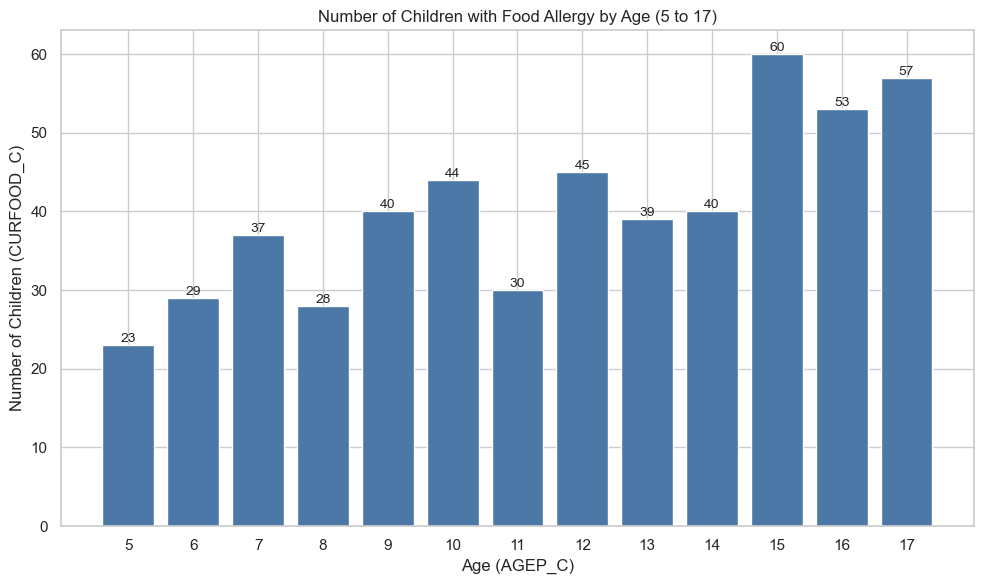

In [63]:
# The number of children having food allergy by age (5 to 17)

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Keep valid ages 5-17
age_series = pd.to_numeric(allergy_yes["AGEP_C"], errors="coerce")
age_series = age_series[age_series.between(5, 17)]

# Fixed age order 5~17, fill missing ages with 0
age_counts = age_series.value_counts().reindex(range(5, 18), fill_value=0)

plt.figure(figsize=(10, 6))
bars = plt.bar(age_counts.index.astype(str), age_counts.values, color="#4C78A8")

# Show exact counts on bars
for bar, value in zip(bars, age_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Number of Children with Food Allergy by Age (5 to 17)")
plt.xlabel("Age (AGEP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.tight_layout()
plt.show()

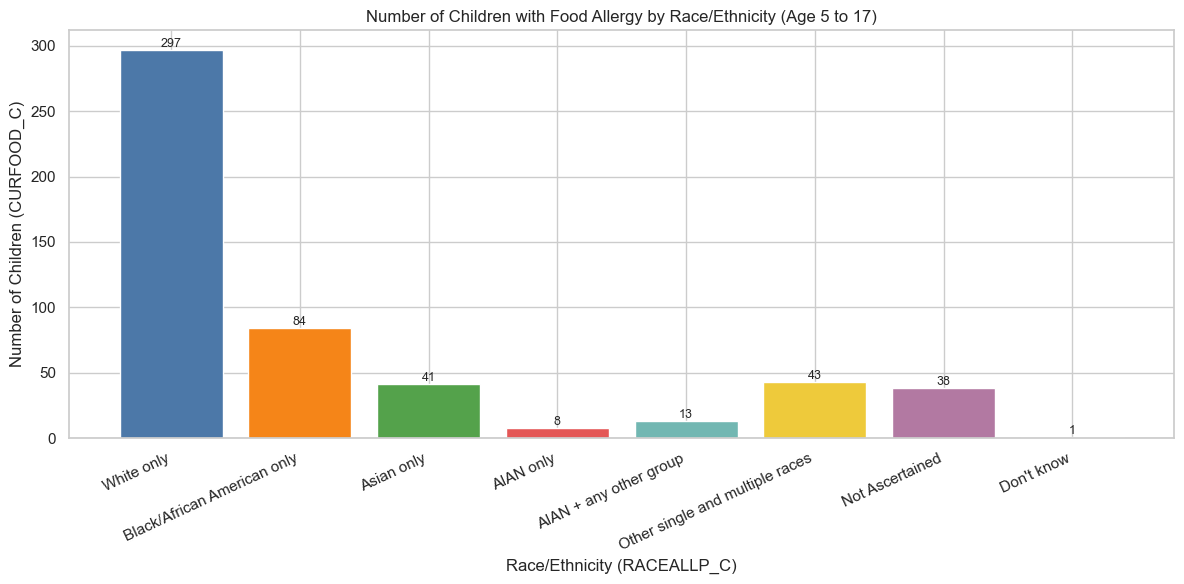

In [64]:
# The number of children having food allergy by race/ethnicity (age 5 to 17)

race_labels_map = {
    1: "White only",
    2: "Black/African American only",
    3: "Asian only",
    4: "AIAN only",
    5: "AIAN + any other group",
    6: "Other single and multiple races",
    7: "Refused",
    8: "Not Ascertained",
    9: "Don't know"
}

# Keep only children with current food allergy = Yes (1)
allergy_yes = children_with_age_range[
    pd.to_numeric(children_with_age_range["CURFOOD_C"], errors="coerce") == 1
].copy()

# Count by race/ethnicity
race_series = pd.to_numeric(allergy_yes["RACEALLP_C"], errors="coerce")
race_counts = race_series.value_counts().sort_index()
race_labels = [race_labels_map.get(int(code), f"Code {int(code)}") for code in race_counts.index]

bar_colors = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2",
    "#EECA3B", "#B279A2", "#FF9DA6", "#9D755D"
][:len(race_counts)]

plt.figure(figsize=(12, 6))
bars = plt.bar(race_labels, race_counts.values, color=bar_colors)

# Show exact counts on bars
for bar, value in zip(bars, race_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Number of Children with Food Allergy by Race/Ethnicity (Age 5 to 17)")
plt.xlabel("Race/Ethnicity (RACEALLP_C)")
plt.ylabel("Number of Children (CURFOOD_C)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# Analysis

What factors are associated with health status among children with food allergies?  
How does this differ when compared to children without food allergies?

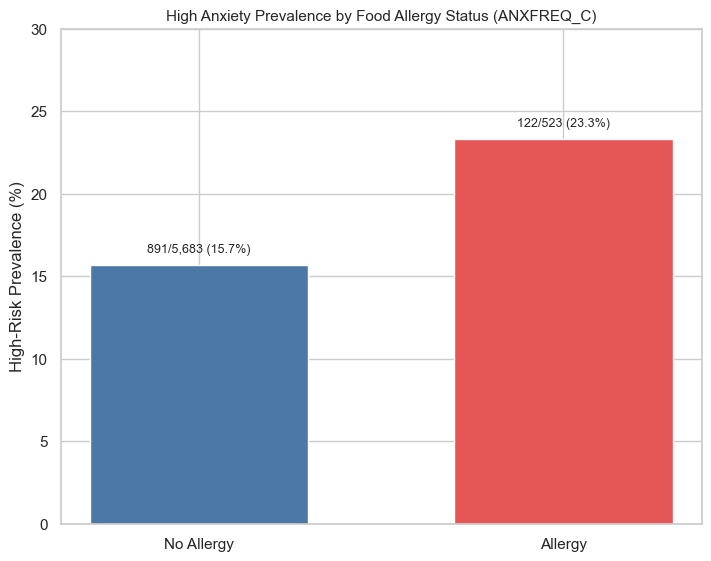

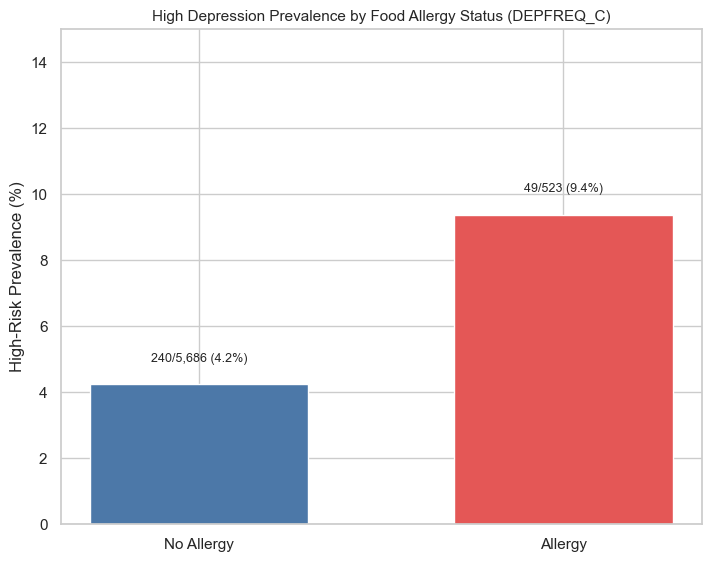

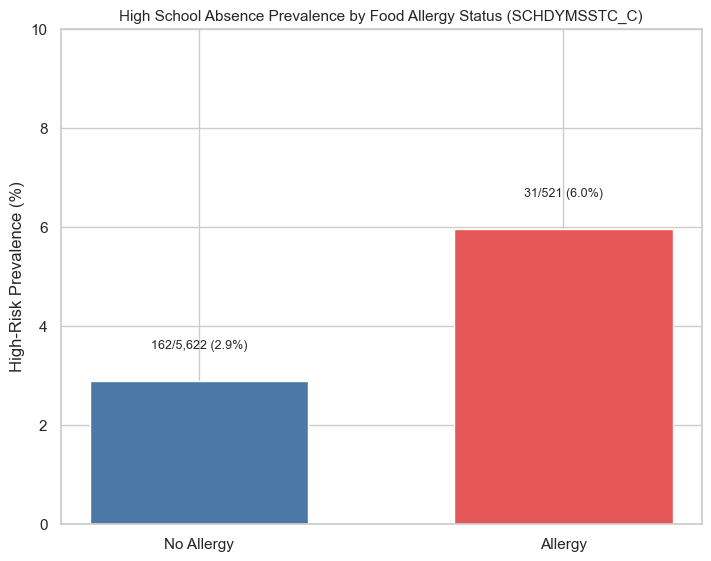


=== high_anxiety ===


high_anxiety,Not High-Risk,High-Risk
food_allergy,,
No Allergy,4792,891
Allergy,401,122


chi2 = 19.9569, p-value = 7.92095e-06, dof = 1

=== high_depression ===


high_depression,Not High-Risk,High-Risk
food_allergy,,
No Allergy,5446,240
Allergy,474,49


chi2 = 27.4546, p-value = 1.60825e-07, dof = 1

=== high_absence ===


high_absence,Not High-Risk,High-Risk
food_allergy,,
No Allergy,5460,162
Allergy,490,31


chi2 = 13.7627, p-value = 0.000207419, dof = 1


In [65]:
from scipy.stats import chi2_contingency

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2]), 1,
    np.where(dep.isin([3, 4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    (sch >= 18) & (sch <= 95), 1,
    np.where((sch >= 0) & (sch <= 17), 0, np.nan)
)

# -----------------------------------
# 2) Plots
# -----------------------------------
sns.set_theme(style="whitegrid")

outcomes = [
    ("high_anxiety", "High Anxiety Prevalence by Food Allergy Status"),
    ("high_depression", "High Depression Prevalence by Food Allergy Status"),
    ("high_absence", "High School Absence Prevalence by Food Allergy Status (SCHDYMSSTC_C)"),
]

colors = ["#4C78A8", "#E45756"]
chi_results = []
plot_data = {}

for outcome, title in outcomes:
    sub = df.dropna(subset=["food_allergy", outcome]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[outcome] = sub[outcome].astype(int)

    ct = pd.crosstab(sub["food_allergy"], sub[outcome]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )

    high_counts = ct[1]
    totals = ct.sum(axis=1)
    high_pct = high_counts / totals * 100

    plot_data[outcome] = {
        "title": title,
        "high_counts": high_counts,
        "totals": totals,
        "high_pct": high_pct,
    }

    chi2, p, dof, exp = chi2_contingency(ct)
    chi_results.append({
        "Outcome": outcome,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "crosstab": ct
    })

# 2a) High anxiety + high depression in one row
panel_outcomes = ["high_anxiety", "high_depression"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), constrained_layout=True)

for ax, outcome in zip(axes, panel_outcomes):
    item = plot_data[outcome]
    x_labels = ["No Allergy", "Allergy"]
    y_vals = [item["high_pct"].loc[0], item["high_pct"].loc[1]]
    bars = ax.bar(x_labels, y_vals, color=colors, width=0.6)

    for i, grp in enumerate([0, 1]):
        cnt = int(item["high_counts"].loc[grp])
        tot = int(item["totals"].loc[grp])
        pct = float(item["high_pct"].loc[grp])
        ax.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.5,
            f"{pct:.1f}%\n({cnt:,}/{tot:,})",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="semibold"
        )

    ax.set_title(item["title"], fontsize=11, fontweight="semibold")
    ax.set_ylabel("Prevalence (%)")

    if outcome == "high_anxiety":
        ax.set_ylim(0, 30)
    else:
        ax.set_ylim(0, 12)

plt.show()

# 2b) Keep high absence as a separate plot
item = plot_data["high_absence"]
fig, ax = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
x_labels = ["No Allergy", "Allergy"]
y_vals = [item["high_pct"].loc[0], item["high_pct"].loc[1]]
bars = ax.bar(x_labels, y_vals, color=colors, width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(item["high_counts"].loc[grp])
    tot = int(item["totals"].loc[grp])
    pct = float(item["high_pct"].loc[grp])
    ax.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.4,
        f"{cnt:,}/{tot:,} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(item["title"], fontsize=11)
ax.set_ylabel("High-Risk Prevalence (%)")
ax.set_ylim(0, 10)
plt.show()

# -----------------------------------
# 3) Crosstabs + chi-square results
# -----------------------------------
for r in chi_results:
    print(f"\n=== {r['Outcome']} ===")
    ct_show = r["crosstab"].rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Not High-Risk", 1: "High-Risk"}
    )
    display(ct_show)
    print(f"chi2 = {r['chi2']:.4f}, p-value = {r['p_value']:.6g}, dof = {r['dof']}")


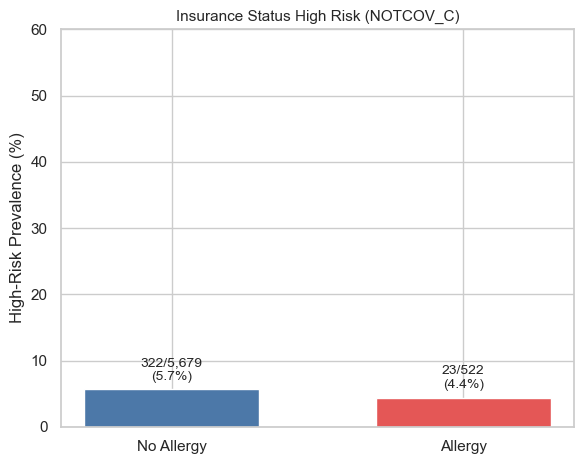

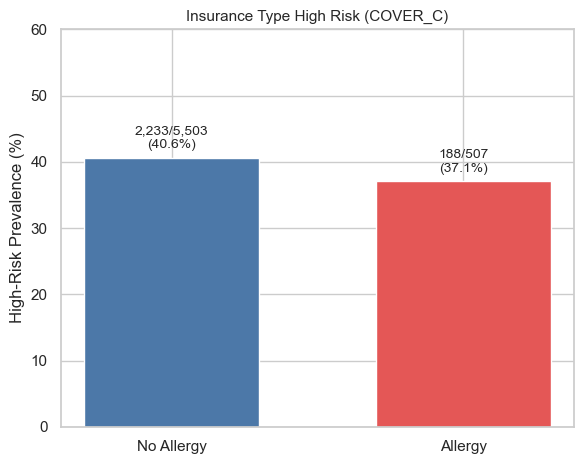

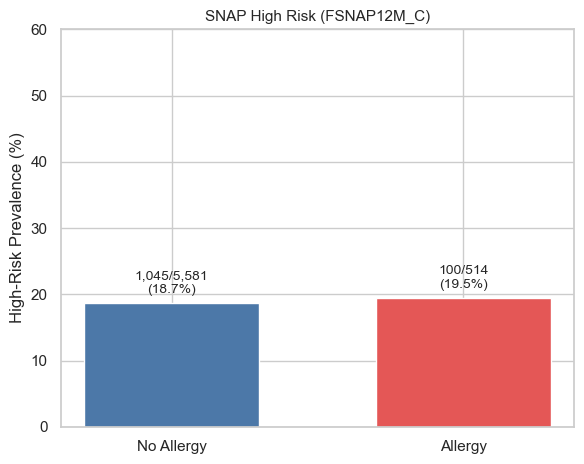

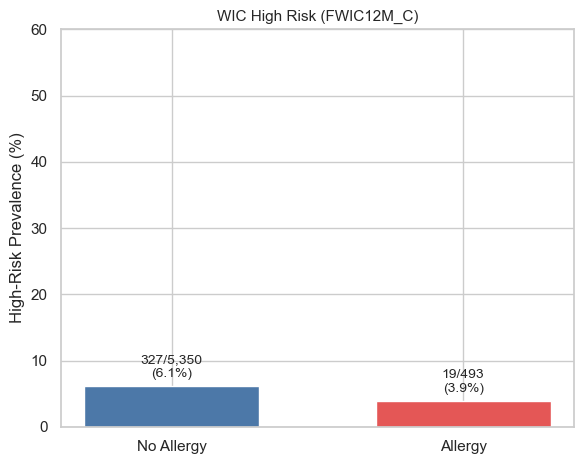

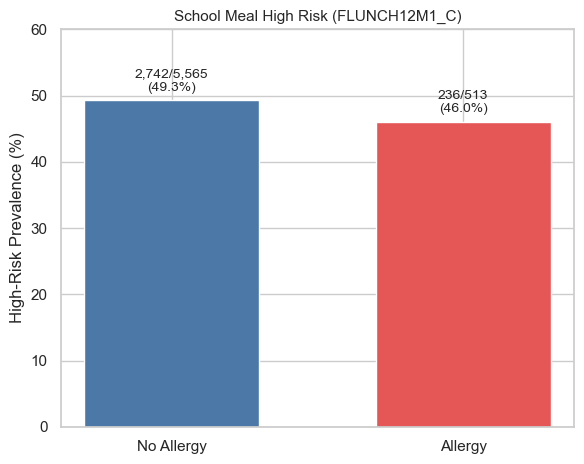

### Insurance Status High Risk (NOTCOV_C)

,Low Risk (0),High Risk (1)
No Allergy,5357,322
Allergy,499,23


,chi_square,p_value,degrees_of_freedom,significant
0,1.2228,0.2688,1,False


### Insurance Type High Risk (COVER_C)

,Low Risk (0),High Risk (1)
No Allergy,3270,2233
Allergy,319,188


...

,Low Risk (0),High Risk (1)
No Allergy,5023,327
Allergy,474,19


,chi_square,p_value,degrees_of_freedom,significant
0,3.7366,0.0532,1,False


### School Meal High Risk (FLUNCH12M1_C)

,Low Risk (0),High Risk (1)
No Allergy,2823,2742
Allergy,277,236


,chi_square,p_value,degrees_of_freedom,significant
0,1.8791,0.1704,1,False


In [66]:
# -----------------------------------
# 1) Base data: age 5-17, keep both allergy groups
# -----------------------------------
df = children_with_age_range.copy()
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------------
# 2) Recode socioeconomic variables to binary risk
# -----------------------------------
def recode_notcov(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1  # uninsured = high risk
    out[s == 2] = 0  # insured = low risk
    return out

def recode_cover(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 0
    out[s.isin([2, 4])] = 1
    return out

def recode_yesno_risk(s):
    s = pd.to_numeric(s, errors="coerce")
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1
    out[s == 2] = 0
    return out

df["notcov_risk"] = recode_notcov(df["NOTCOV_C"])
df["cover_risk"] = recode_cover(df["COVER_C"])
df["food_stamp_risk"] = recode_yesno_risk(df["FSNAP12M_C"])
df["wic_risk"] = recode_yesno_risk(df["FWIC12M_C"])
df["meal_risk"] = recode_yesno_risk(df["FLUNCH12M1_C"])

# -----------------------------------
# 3) Plot each variable separately (1 row, 1 chart each)
# -----------------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("notcov_risk", "Insurance Status High Risk (NOTCOV_C)"),
    ("cover_risk", "Insurance Type High Risk (COVER_C)"),
    ("food_stamp_risk", "SNAP High Risk (FSNAP12M_C)"),
    ("wic_risk", "WIC High Risk (FWIC12M_C)"),
    ("meal_risk", "School Meal High Risk (FLUNCH12M1_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pct = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(6, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pct.loc[0], pct.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        p = float(pct.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 1.0,
            f"{cnt:,}/{tot:,}\n({p:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title, fontsize=11)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 60)
    plt.tight_layout()
    plt.show()

from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# -----------------------------------
# 4) Chi-square test for each variable separately
# -----------------------------------
for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    contingency = pd.crosstab(sub["food_allergy"], sub[col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    contingency.index = ["No Allergy", "Allergy"]
    contingency.columns = ["Low Risk (0)", "High Risk (1)"]

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    display(Markdown(f"### {title}"))
    display(contingency)

    result_df = pd.DataFrame({
        "chi_square": [round(chi2, 4)],
        "p_value": [round(p_value, 4)],
        "degrees_of_freedom": [dof],
        "significant": [p_value < 0.05]
    })
    display(result_df)


Crosstab: Count


,cover_group,No Allergy,Allergy
0,Medicaid or other public,1911,165
1,Other coverage,176,15
2,Private,3270,319
3,Uninsured,322,23


Crosstab: Row Percentage


,cover_group,No Allergy (%),Allergy (%)
0,Medicaid or other public,92.05,7.95
1,Other coverage,92.15,7.85
2,Private,91.11,8.89
3,Uninsured,93.33,6.67


Food allergy by COVER_C category


,cover_group,allergy_count,total_n,allergy_percent
0,Medicaid or other public,165,2076,7.95
1,Other coverage,15,191,7.85
2,Private,319,3589,8.89
3,Uninsured,23,345,6.67


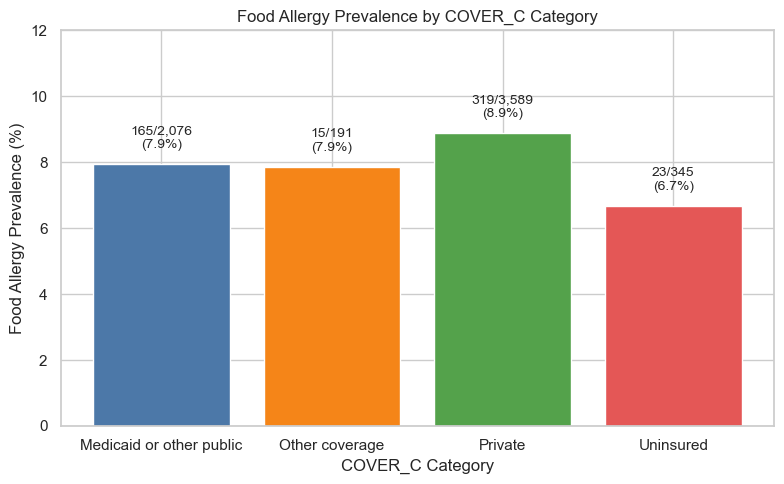

In [67]:
# -----------------------------------
# COVER_C: food allergy count and percentage by category
# -----------------------------------
df = children_with_age_range.copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

cover = pd.to_numeric(df["COVER_C"], errors="coerce")

# Keep the original COVER_C categories
# If needed, adjust the label_map below to match the codebook
label_map = {
    1: "Private",
    2: "Medicaid or other public",
    3: "Other coverage",
    4: "Uninsured"
}

df["cover_group"] = cover.map(label_map)

analysis_df = df.dropna(subset=["food_allergy", "cover_group"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)

# Count table
ct_count = pd.crosstab(analysis_df["cover_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

# Row percentage
ct_pct = pd.crosstab(
    analysis_df["cover_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

print("Crosstab: Count")
display(ct_count.reset_index(names="cover_group"))

print("Crosstab: Row Percentage")
display(ct_pct.round(2).reset_index(names="cover_group"))

# Allergy count / total / prevalence
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)
allergy_pct = ct_pct["Allergy (%)"]

summary_df = pd.DataFrame({
    "cover_group": ct_count.index,
    "allergy_count": allergy_counts.values,
    "total_n": group_totals.values,
    "allergy_percent": allergy_pct.values
})

print("Food allergy by COVER_C category")
display(summary_df.round(2))

# Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(summary_df["cover_group"], summary_df["allergy_percent"],
               color=["#4C78A8", "#F58518", "#54A24B", "#E45756"])

plt.ylim(0, 12)

for i, bar in enumerate(bars):
    cnt = int(summary_df.iloc[i]["allergy_count"])
    tot = int(summary_df.iloc[i]["total_n"])
    pct = float(summary_df.iloc[i]["allergy_percent"])
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by COVER_C Category")
plt.xlabel("COVER_C Category")
plt.ylabel("Food Allergy Prevalence (%)")
plt.tight_layout()
plt.show()


2x2 Table: Count


,No Allergy,Allergy
education_binary,,
0-5,2202,156
6-10,3338,360


2x2 Table: Row Percentage


,No Allergy (%),Allergy (%)
education_binary,,
0-5,93.38,6.62
6-10,90.27,9.73


Chi-square Test Result


,chi_square,p_value,degrees_of_freedom,significant
0,17.5754,0.000028,1,True


Expected Counts


,No Allergy,Allergy
education_binary,,
0-5,2157.09,200.91
6-10,3382.91,315.09


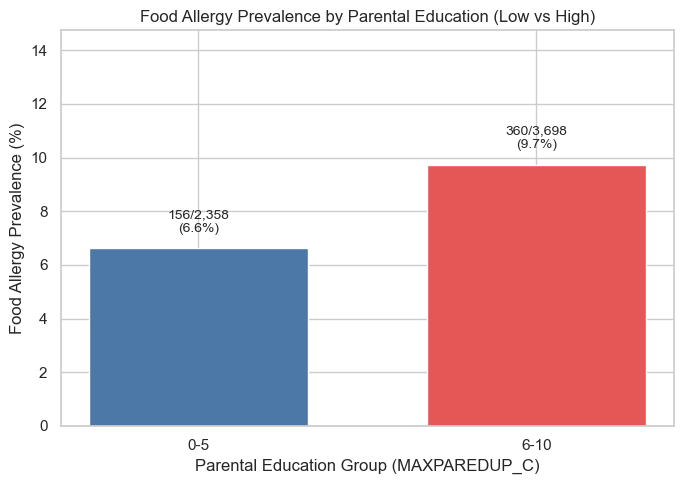

In [68]:
from scipy.stats import chi2_contingency

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# MAXPAREDUP_C recode: 0-5 vs 6-10
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")
df["education_binary"] = np.where(
    maxedu.between(0, 5), "0-5",
    np.where(maxedu.between(6, 10), "6-10", pd.NA)
)

# Remove missing values
analysis_df = df.dropna(subset=["education_binary", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["education_binary"] = pd.Categorical(
    analysis_df["education_binary"],
    categories=["0-5", "6-10"],
    ordered=True
)

# -----------------------------------
# 2) 2x2 contingency table
# -----------------------------------
ct_count = pd.crosstab(analysis_df["education_binary"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["0-5", "6-10"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["education_binary"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["0-5", "6-10"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

print("2x2 Table: Count")
display(ct_count)

print("2x2 Table: Row Percentage")
display(ct_pct.round(2))

# -----------------------------------
# 3) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 10)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square Test Result")
display(chi_result)

expected_df = pd.DataFrame(
    expected,
    index=ct_count.index,
    columns=ct_count.columns
)

print("Expected Counts")
display(expected_df.round(2))

# -----------------------------------
# 4) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(prev_pct.index, prev_pct.values, color=["#4C78A8", "#E45756"], width=0.65)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Parental Education (Low vs High)")
plt.xlabel("Parental Education Group (MAXPAREDUP_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, max(prev_pct.values) + 5)
plt.tight_layout()
plt.show()


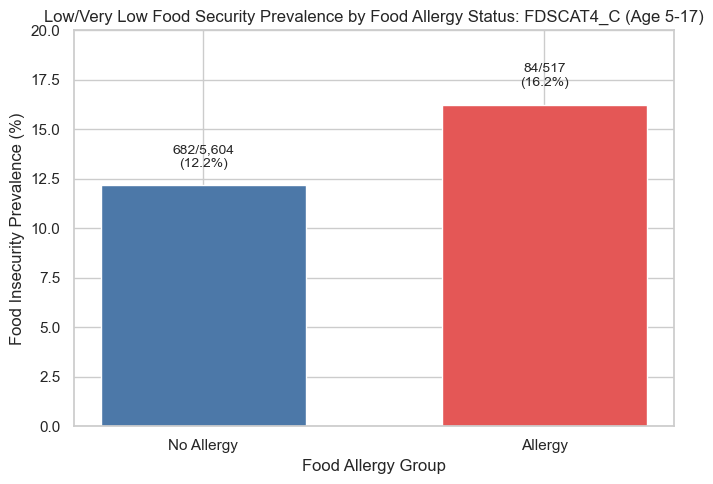

Crosstab (count):


food_insecure,High/Marginal,Low/Very Low
food_allergy,,
No Allergy,4922,682
Allergy,433,84


Chi-square test result


,chi_square,p_value,degrees_of_freedom,significant
0,6.8211,0.009009,1,True


In [69]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age range: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C: 1=Allergy, 2=No Allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) FDSCAT4_C -> food_insecure
# 3,4 -> 1 (Low/Very Low), 1,2 -> 0 (High/Marginal), others(8,etc.) -> NaN
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "food_insecure"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["food_insecure"] = analysis_df["food_insecure"].astype(int)

# -----------------------------------
# 2) Crosstab + prevalence
# -----------------------------------
ct = pd.crosstab(analysis_df["food_allergy"], analysis_df["food_insecure"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy
# col 1: Low/Very Low food security count

insecure_counts = ct[1]
totals = ct.sum(axis=1)
insecure_pct = (insecure_counts / totals * 100)



# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

x_labels = ["No Allergy", "Allergy"]
y_vals = [insecure_pct.loc[0], insecure_pct.loc[1]]
bars = plt.bar(x_labels, y_vals, color=["#4C78A8", "#E45756"], width=0.6)

for i, grp in enumerate([0, 1]):
    cnt = int(insecure_counts.loc[grp])
    tot = int(totals.loc[grp])
    pct = float(insecure_pct.loc[grp])
    plt.text(
        bars[i].get_x() + bars[i].get_width() / 2,
        bars[i].get_height() + 0.8,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Low/Very Low Food Security Prevalence by Food Allergy Status: FDSCAT4_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Food Insecurity Prevalence (%)")
plt.ylim(0, 20)
plt.tight_layout()
plt.show()


# Display crosstab
ct_show = ct.rename(index={0: "No Allergy", 1: "Allergy"},
                    columns={0: "High/Marginal", 1: "Low/Very Low"})
print("Crosstab (count):")
display(ct_show)

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 6)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square test result")
display(chi_result)



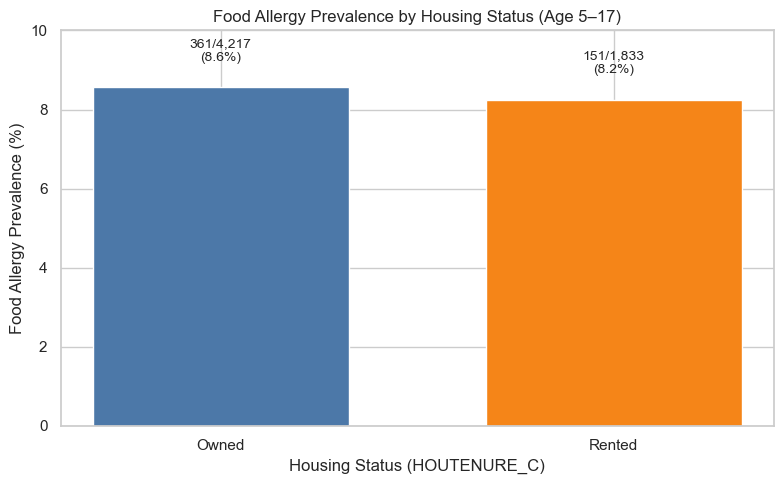

Chi-square test result


,chi_square,p_value,degrees_of_freedom,significant
0,0.1326,0.715706,1,False


2x2 Table: Count


,No Allergy,Allergy
housing_group,,
Owned,3856,361
Rented,1682,151


2x2 Table: Row Percentage


,No Allergy (%),Allergy (%)
housing_group,,
Owned,91.44,8.56
Rented,91.76,8.24


In [70]:
# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# (1) Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# (2) CURFOOD_C recode: 1->1, 2->0, else NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# (3) HOUTENURE_C recode
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
housing_map = {1: "Owned", 2: "Rented"}
df["housing_group"] = house.map(housing_map)  # 7,8,9 and others -> NaN


# Remove missing values
analysis_df = df.dropna(subset=["housing_group", "food_allergy"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["housing_group"] = pd.Categorical(
    analysis_df["housing_group"],
    categories=["Owned", "Rented"],
    ordered=True
)

# -----------------------------------
# 2) Crosstab (count + row %)
# -----------------------------------
ct_count = pd.crosstab(analysis_df["housing_group"], analysis_df["food_allergy"])
ct_count = ct_count.reindex(index=["Owned", "Rented"], columns=[0, 1], fill_value=0)
ct_count.columns = ["No Allergy", "Allergy"]

ct_pct = pd.crosstab(
    analysis_df["housing_group"],
    analysis_df["food_allergy"],
    normalize="index"
) * 100
ct_pct = ct_pct.reindex(index=["Owned", "Rented"], columns=[0, 1], fill_value=0)
ct_pct.columns = ["No Allergy (%)", "Allergy (%)"]

# Display tables with one-line header style
# print("Crosstab: Count")
# display(ct_count.rename_axis(None).reset_index(names="housing_group"))

# print("Crosstab: Row Percentage")
# display(ct_pct.round(2).rename_axis(None).reset_index(names="housing_group"))

# -----------------------------------
# 3) Bar chart
# -----------------------------------
prev_pct = ct_pct["Allergy (%)"]
allergy_counts = ct_count["Allergy"]
group_totals = ct_count.sum(axis=1)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
bars = plt.bar(
    prev_pct.index,
    prev_pct.values,
    color=["#4C78A8", "#F58518"],
    width=0.65
)

for i, bar in enumerate(bars):
    grp = prev_pct.index[i]
    cnt = int(allergy_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = prev_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.6,
        f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Food Allergy Prevalence by Housing Status (Age 5–17)")
plt.xlabel("Housing Status (HOUTENURE_C)")
plt.ylabel("Food Allergy Prevalence (%)")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

from scipy.stats import chi2_contingency

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 6)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square test result")
display(chi_result)

expected_df = pd.DataFrame(
    expected,
    index=ct_count.index,
    columns=ct_count.columns
)

print("2x2 Table: Count")
display(ct_count)

print("2x2 Table: Row Percentage")
display(ct_pct.round(2))


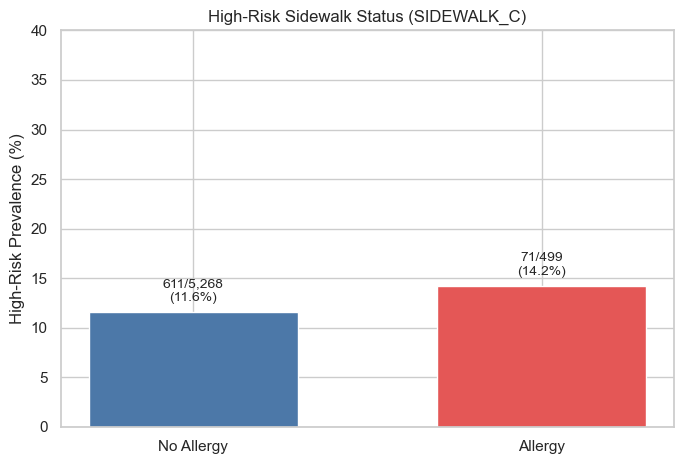

**High-Risk Sidewalk Status (SIDEWALK_C): 2x2 Table**

sidewalk_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4657,611
Allergy,428,71


**High-Risk Sidewalk Status (SIDEWALK_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.777,0.095629,1,False


**High-Risk Sidewalk Status (SIDEWALK_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4645.01,622.99
Allergy,439.99,59.01


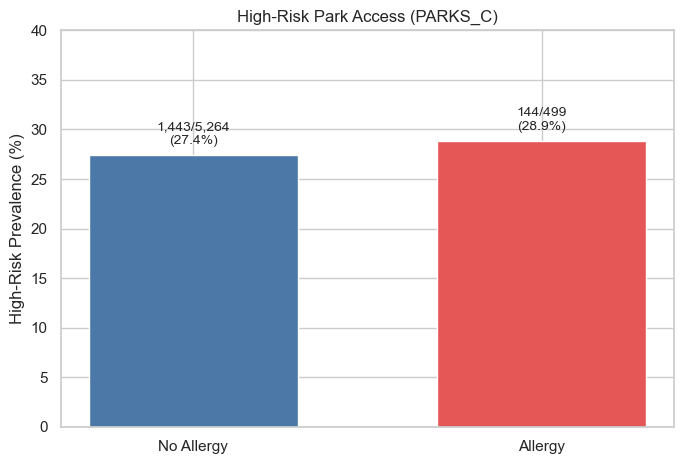

**High-Risk Park Access (PARKS_C): 2x2 Table**

parks_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3821,1443
Allergy,355,144


**High-Risk Park Access (PARKS_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,0.4073,0.523325,1,False


**High-Risk Park Access (PARKS_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3814.41,1449.59
Allergy,361.59,137.41


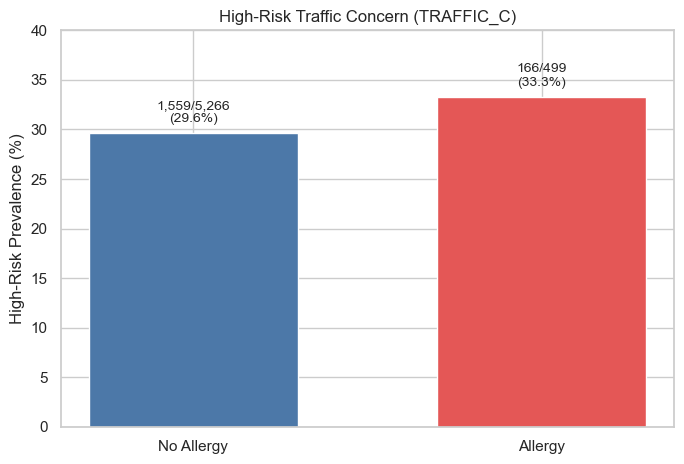

**High-Risk Traffic Concern (TRAFFIC_C): 2x2 Table**

traffic_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3707,1559
Allergy,333,166


**High-Risk Traffic Concern (TRAFFIC_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.7423,0.097725,1,False


**High-Risk Traffic Concern (TRAFFIC_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3690.31,1575.69
Allergy,349.69,149.31


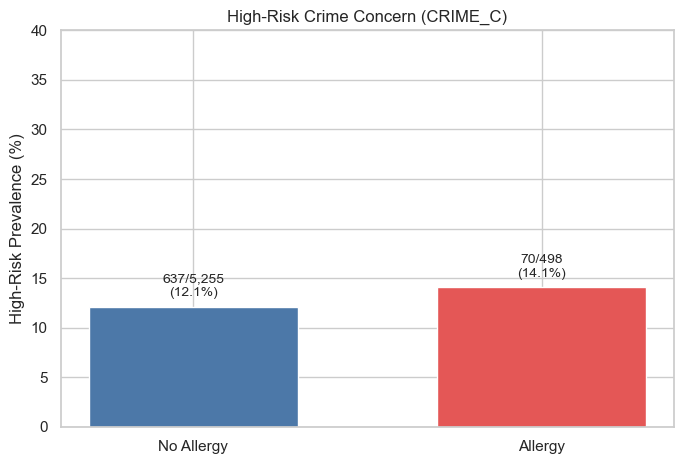

**High-Risk Crime Concern (CRIME_C): 2x2 Table**

crime_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4618,637
Allergy,428,70


**High-Risk Crime Concern (CRIME_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,1.4048,0.235915,1,False


**High-Risk Crime Concern (CRIME_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4609.2,645.8
Allergy,436.8,61.2


In [71]:
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# -----------------------------
# 1) Filter: age 5-17 + keep both allergy groups
# -----------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------
# 2) Recode built environment to high-risk indicators
# -----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

sidewalk = to_num(df["SIDEWALK_C"])
parks = to_num(df["PARKS_C"])
traffic = to_num(df["TRAFFIC_C"])
crime = to_num(df["CRIME_C"])

# High-risk:
# Sidewalk/Parks: No(2)=1 high-risk, Yes(1)=0
# Traffic/Crime: Yes(1)=1 high-risk, No(2)=0
df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# -----------------------------
# 3) Plot each variable separately
# -----------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("sidewalk_high_risk", "High-Risk Sidewalk Status (SIDEWALK_C)"),
    ("parks_high_risk", "High-Risk Park Access (PARKS_C)"),
    ("traffic_high_risk", "High-Risk Traffic Concern (TRAFFIC_C)"),
    ("crime_high_risk", "High-Risk Crime Concern (CRIME_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pcts = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(7, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pcts.loc[0], pcts.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(pcts.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.8,
            f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 40)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 4) 2x2 table + chi-square result for each variable
    # -----------------------------
    ct = pd.crosstab(sub["food_allergy"], sub[col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    ct_show = ct.rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Low Risk (0)", 1: "High Risk (1)"}
    )

    chi2, p_value, dof, expected = chi2_contingency(ct)

    chi_result = pd.DataFrame({
        "chi_square": [round(chi2, 4)],
        "p_value": [round(p_value, 6)],
        "degrees_of_freedom": [dof],
        "significant": [p_value < 0.05]
    })

    display(Markdown(f"**{title}: 2x2 Table**"))
    display(ct_show)

    display(Markdown(f"**{title}: Chi-square Test Result**"))
    display(chi_result)

    expected_df = pd.DataFrame(
        expected,
        index=["No Allergy", "Allergy"],
        columns=["Low Risk (0)", "High Risk (1)"]
    )

    display(Markdown(f"**{title}: Expected Counts**"))
    display(expected_df.round(2))


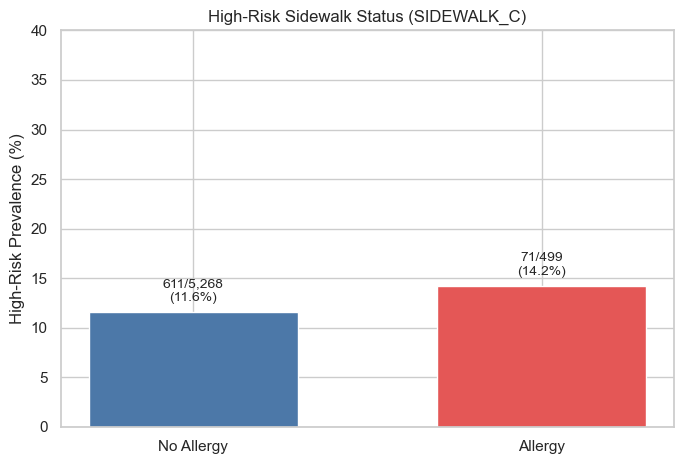

**High-Risk Sidewalk Status (SIDEWALK_C): 2x2 Table**

sidewalk_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4657,611
Allergy,428,71


**High-Risk Sidewalk Status (SIDEWALK_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.777,0.095629,1,False


**High-Risk Sidewalk Status (SIDEWALK_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4645.01,622.99
Allergy,439.99,59.01


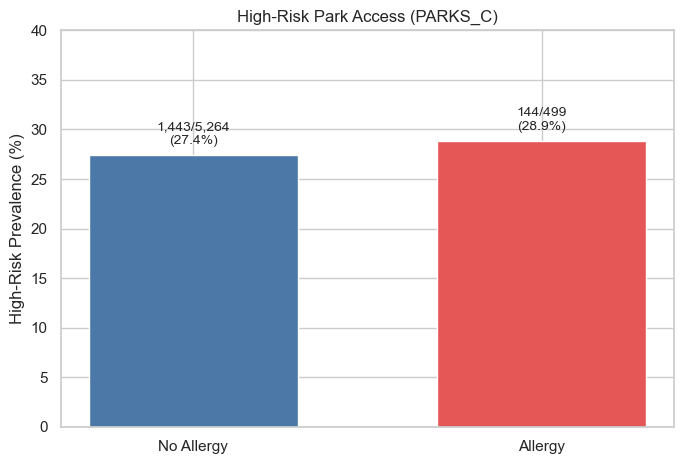

**High-Risk Park Access (PARKS_C): 2x2 Table**

parks_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3821,1443
Allergy,355,144


**High-Risk Park Access (PARKS_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,0.4073,0.523325,1,False


**High-Risk Park Access (PARKS_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3814.41,1449.59
Allergy,361.59,137.41


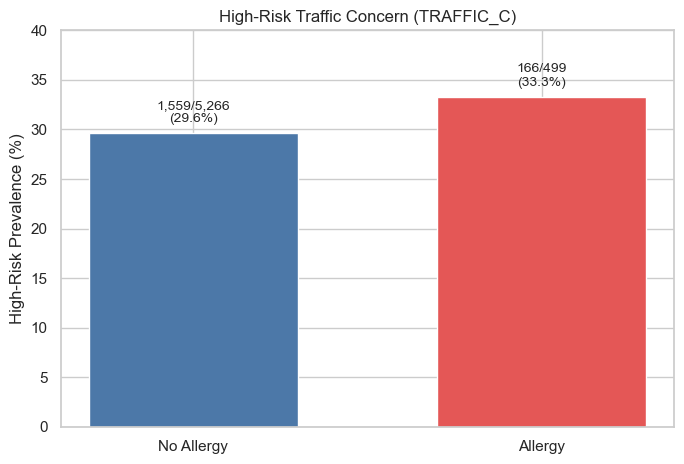

**High-Risk Traffic Concern (TRAFFIC_C): 2x2 Table**

traffic_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,3707,1559
Allergy,333,166


**High-Risk Traffic Concern (TRAFFIC_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,2.7423,0.097725,1,False


**High-Risk Traffic Concern (TRAFFIC_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,3690.31,1575.69
Allergy,349.69,149.31


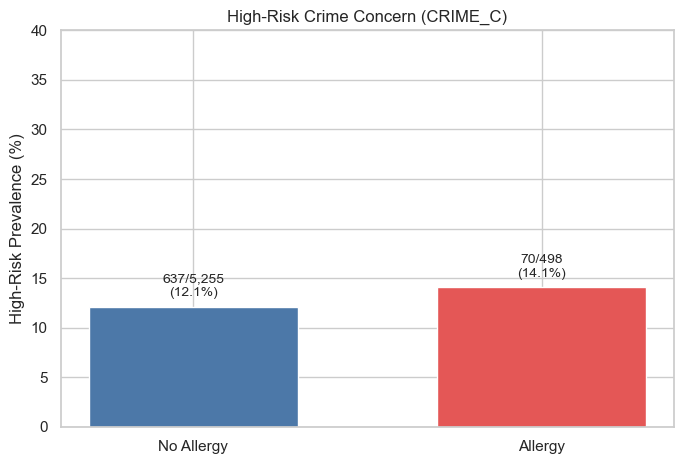

**High-Risk Crime Concern (CRIME_C): 2x2 Table**

crime_high_risk,Low Risk (0),High Risk (1)
food_allergy,,
No Allergy,4618,637
Allergy,428,70


**High-Risk Crime Concern (CRIME_C): Chi-square Test Result**

,chi_square,p_value,degrees_of_freedom,significant
0,1.4048,0.235915,1,False


**High-Risk Crime Concern (CRIME_C): Expected Counts**

,Low Risk (0),High Risk (1)
No Allergy,4609.2,645.8
Allergy,436.8,61.2


In [72]:
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown

# -----------------------------
# 1) Filter: age 5-17 + keep both allergy groups
# -----------------------------
df = child_data.copy()

age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# -----------------------------
# 2) Recode built environment to high-risk indicators
# -----------------------------
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

sidewalk = to_num(df["SIDEWALK_C"])
parks = to_num(df["PARKS_C"])
traffic = to_num(df["TRAFFIC_C"])
crime = to_num(df["CRIME_C"])

# High-risk:
# Sidewalk/Parks: No(2)=1 high-risk, Yes(1)=0
# Traffic/Crime: Yes(1)=1 high-risk, No(2)=0
df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# -----------------------------
# 3) Plot each variable separately
# -----------------------------
sns.set_theme(style="whitegrid")

plot_specs = [
    ("sidewalk_high_risk", "High-Risk Sidewalk Status (SIDEWALK_C)"),
    ("parks_high_risk", "High-Risk Park Access (PARKS_C)"),
    ("traffic_high_risk", "High-Risk Traffic Concern (TRAFFIC_C)"),
    ("crime_high_risk", "High-Risk Crime Concern (CRIME_C)"),
]

for col, title in plot_specs:
    sub = df.dropna(subset=["food_allergy", col]).copy()
    sub["food_allergy"] = sub["food_allergy"].astype(int)
    sub[col] = sub[col].astype(int)

    totals = sub.groupby("food_allergy")[col].size().reindex([0, 1], fill_value=0)
    high_counts = sub.groupby("food_allergy")[col].sum().reindex([0, 1], fill_value=0)
    pcts = (high_counts / totals.replace(0, np.nan) * 100).fillna(0)

    plt.figure(figsize=(7, 4.8))
    bars = plt.bar(
        ["No Allergy", "Allergy"],
        [pcts.loc[0], pcts.loc[1]],
        color=["#4C78A8", "#E45756"],
        width=0.6
    )

    for i, grp in enumerate([0, 1]):
        cnt = int(high_counts.loc[grp])
        tot = int(totals.loc[grp])
        pct = float(pcts.loc[grp])
        plt.text(
            bars[i].get_x() + bars[i].get_width() / 2,
            bars[i].get_height() + 0.8,
            f"{cnt:,}/{tot:,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.title(title)
    plt.ylabel("High-Risk Prevalence (%)")
    plt.ylim(0, 40)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 4) 2x2 table + chi-square result for each variable
    # -----------------------------
    ct = pd.crosstab(sub["food_allergy"], sub[col]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    ct_show = ct.rename(
        index={0: "No Allergy", 1: "Allergy"},
        columns={0: "Low Risk (0)", 1: "High Risk (1)"}
    )

    chi2, p_value, dof, expected = chi2_contingency(ct)

    chi_result = pd.DataFrame({
        "chi_square": [round(chi2, 4)],
        "p_value": [round(p_value, 6)],
        "degrees_of_freedom": [dof],
        "significant": [p_value < 0.05]
    })

    display(Markdown(f"**{title}: 2x2 Table**"))
    display(ct_show)

    display(Markdown(f"**{title}: Chi-square Test Result**"))
    display(chi_result)

    expected_df = pd.DataFrame(
        expected,
        index=["No Allergy", "Allergy"],
        columns=["Low Risk (0)", "High Risk (1)"]
    )

    display(Markdown(f"**{title}: Expected Counts**"))
    display(expected_df.round(2))


Poor health among children with food allergy only:
39/525 (7.43%)


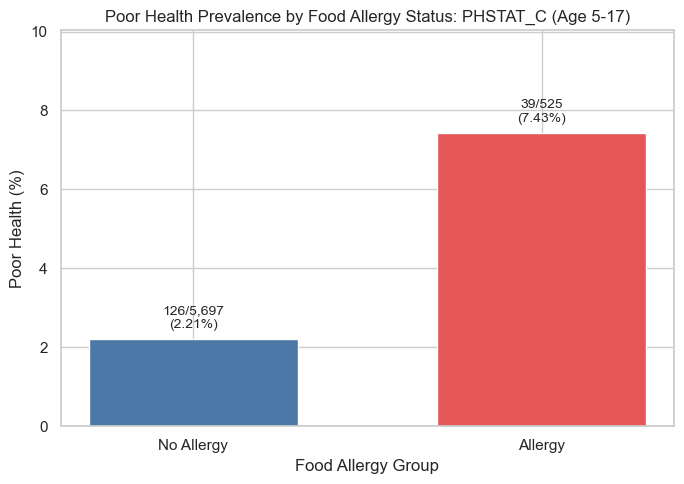


Crosstab (count):


poor_health,Not Poor,Poor
food_allergy,,
No Allergy,5571,126
Allergy,486,39


Chi-square test result:


,chi_square,p_value,degrees_of_freedom,significant
0,48.6769,3.018004e-12,1,True


Expected counts:


,Not Poor,Poor
No Allergy,5545.92,151.08
Allergy,511.08,13.92


In [73]:
# CURFOOD_C vs. PHSTAT_C

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# CURFOOD_C recode: 1=Allergy, 2=No allergy, others=NaN
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# PHSTAT_C recode: 4/5=Poor health(1), 1/2/3=Not poor(0), others=NaN
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Remove missing
analysis_df = df.dropna(subset=["food_allergy", "poor_health"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["poor_health"] = analysis_df["poor_health"].astype(int)

# -----------------------------------
# 2) Analysis
# -----------------------------------
# (1) Poor health prevalence among allergy group only
allergy_only = analysis_df[analysis_df["food_allergy"] == 1]
allergy_poor_rate = allergy_only["poor_health"].mean() * 100
allergy_poor_count = int(allergy_only["poor_health"].sum())
allergy_total = len(allergy_only)

print("Poor health among children with food allergy only:")
print(f"{allergy_poor_count:,}/{allergy_total:,} ({allergy_poor_rate:.2f}%)")

# (2) Compare prevalence by allergy status
ct_count = pd.crosstab(analysis_df["food_allergy"], analysis_df["poor_health"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)
# index: 0 No allergy, 1 Allergy; column 1 = poor health count
poor_pct = (ct_count[1] / ct_count.sum(axis=1) * 100)
poor_pct.index = ["No Allergy", "Allergy"]

poor_counts = ct_count[1].copy()
poor_counts.index = ["No Allergy", "Allergy"]
group_totals = ct_count.sum(axis=1).copy()
group_totals.index = ["No Allergy", "Allergy"]

# -----------------------------------
# 3) Visualization
# -----------------------------------
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(poor_pct.index, poor_pct.values, color=["#4C78A8", "#E45756"], width=0.6)

for i, bar in enumerate(bars):
    grp = poor_pct.index[i]
    cnt = int(poor_counts.loc[grp])
    tot = int(group_totals.loc[grp])
    pct = poor_pct.loc[grp]
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{cnt:,}/{tot:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Poor Health Prevalence by Food Allergy Status: PHSTAT_C (Age 5-17)")
plt.xlabel("Food Allergy Group")
plt.ylabel("Poor Health (%)")
plt.ylim(0, max(5, poor_pct.max() * 1.35))
plt.tight_layout()
plt.show()

# -----------------------------------
# 4) Chi-square test
# -----------------------------------
chi2, p_value, dof, expected = chi2_contingency(ct_count)

ct_show = ct_count.rename(
    index={0: "No Allergy", 1: "Allergy"},
    columns={0: "Not Poor", 1: "Poor"}
)

print("\nCrosstab (count):")
display(ct_show)

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 20)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Chi-square test result:")
display(chi_result)

expected_df = pd.DataFrame(
    expected,
    index=["No Allergy", "Allergy"],
    columns=["Not Poor", "Poor"]
)

print("Expected counts:")
display(expected_df.round(2))


## Logistic Regression for Food Allergy

This section fits a multivariable logistic regression model to identify psychosocial and socioeconomic factors associated with current food allergy among children ages 5-17. Variables are dichotomized using the same logic used earlier in this notebook whenever applicable.


Excluded variables from the logistic regression:
RACEALLP_C,  RELTIVP_C,  FDSCAT3_C,  CURFOOD_C (restricted to allergy only)

Modified model sample size: 449
Poor health = 1: 34
Poor health = 0: 415

Modified logistic regression results:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,4.432635,1.559581,12.598414,0.005209,True
1,High Absence,4.179416,1.450085,12.045857,0.008096,True
2,School Meal High Risk,2.504809,0.994376,6.309552,0.051415,False
3,No Sidewalk High Risk,2.045918,0.699657,5.982619,0.191020,False
4,Food Insecurity,1.757172,0.709298,4.353110,0.223270,False
5,Low Parent Education (0-5 vs 6-10),1.591156,0.661217,3.828969,0.299894,False
6,Housing: Rented vs Owned,1.569480,0.663227,3.714065,0.305075,False
7,No Parks High Risk,1.187424,0.485496,2.904197,0.706575,False
8,WIC High Risk,1.151848,0.232386,5.709258,0.862577,False
9,High Anxiety,1.110424,0.408564,3.017992,0.837321,False



Model comparison:
- Existing model sample size: 6,222
- Modified model sample size: 449


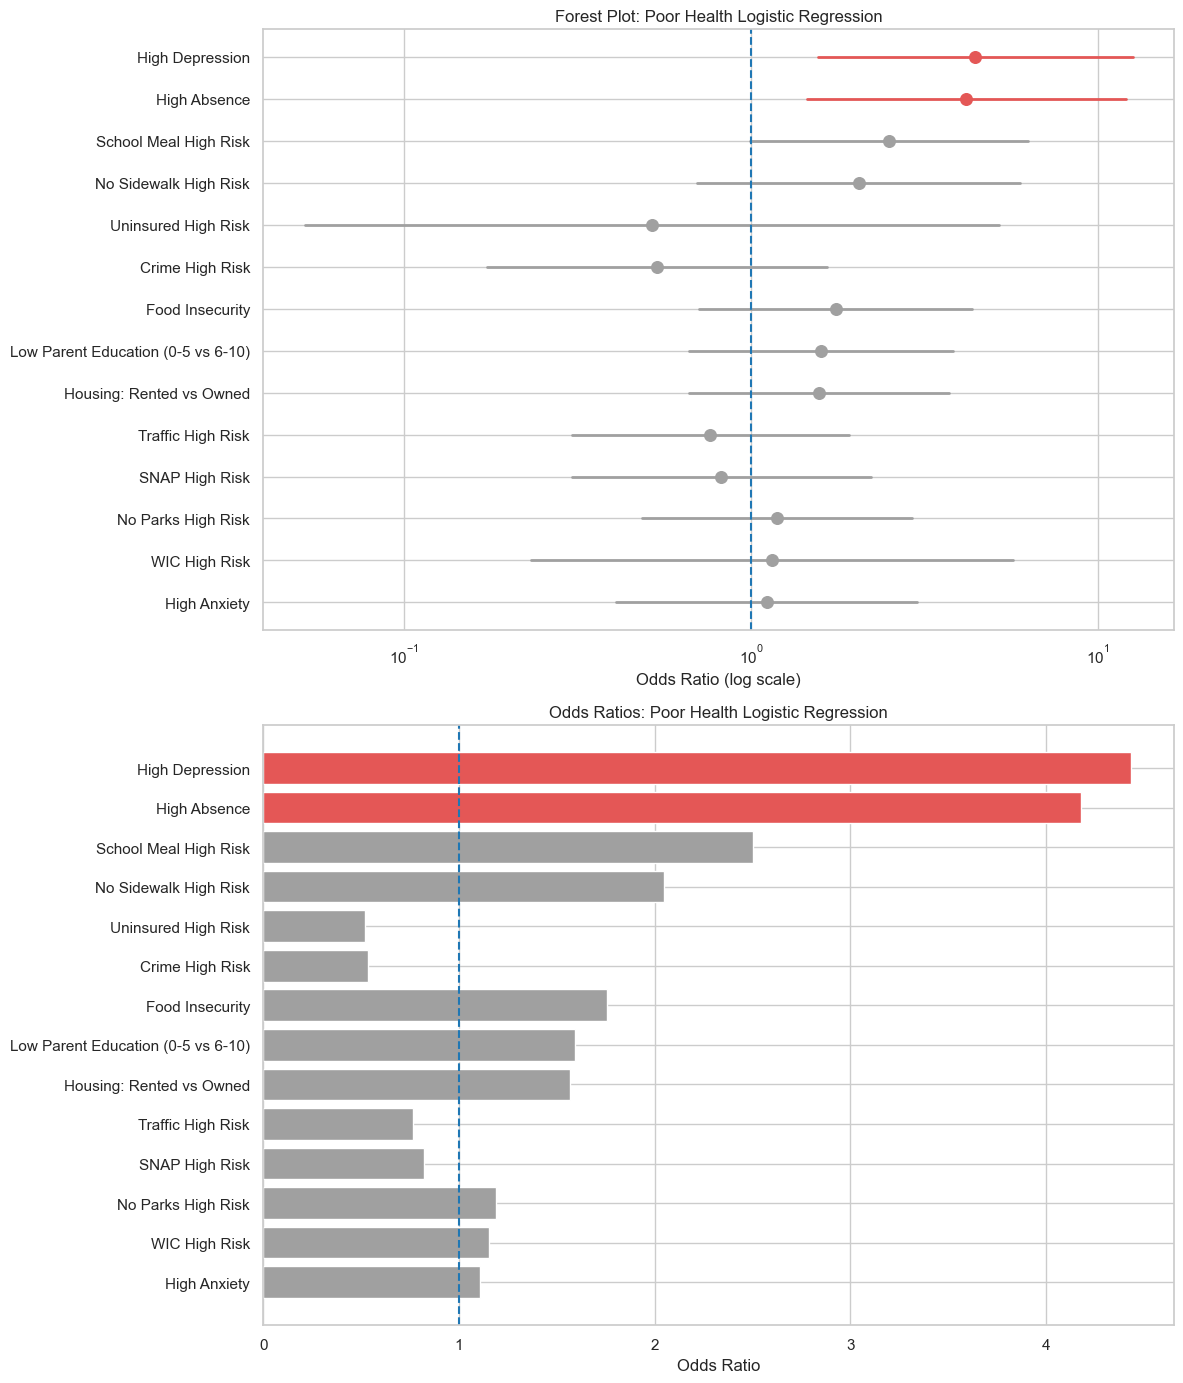

Interpretation:
- High Depression is significantly associated with poor health (OR=4.43, 95% CI 1.56-12.60, p=0.00521). This corresponds to 4.43 times higher odds.
- High Absence is significantly associated with poor health (OR=4.18, 95% CI 1.45-12.05, p=0.0081). This corresponds to 4.18 times higher odds.
- In this modified model, poor health is the outcome.
- The analysis is restricted to children with current food allergy (CURFOOD_C = 1).


In [74]:
import statsmodels.api as sm
from IPython.display import display

# =========================================================
# Modified Logistic Regression
# Outcome = poor_health
# Restricted to children with food allergy
# Age group added
# =========================================================

# -----------------------------------
# 0) Variables excluded from this logistic regression
# -----------------------------------
print("Excluded variables from the logistic regression:")
print("RACEALLP_C, ", "RELTIVP_C, ", "FDSCAT3_C, ", "CURFOOD_C (restricted to allergy only)")

# -----------------------------------
# 1) Data preprocessing
# -----------------------------------
df = child_data.copy()

# Age filter: 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# Restrict to children with food allergy only: CURFOOD_C = 1
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df = df[curfood == 1].copy()

# Outcome: poor health
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Psychosocial
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2, 3]), 1,
    np.where(anx.isin([4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2,3]), 1,
    np.where(dep.isin([4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    sch.between(18, 95), 1,
    np.where(sch.between(0, 17), 0, np.nan)
)

# SDOH / socioeconomic
notcov = pd.to_numeric(df["NOTCOV_C"], errors="coerce")
df["notcov_risk"] = np.where(notcov == 1, 1, np.where(notcov == 2, 0, np.nan))

cover = pd.to_numeric(df["COVER_C"], errors="coerce")

snap = pd.to_numeric(df["FSNAP12M_C"], errors="coerce")
df["snap_risk"] = np.where(snap == 1, 1, np.where(snap == 2, 0, np.nan))

wic = pd.to_numeric(df["FWIC12M_C"], errors="coerce")
df["wic_risk"] = np.where(wic == 1, 1, np.where(wic == 2, 0, np.nan))

meal = pd.to_numeric(df["FLUNCH12M1_C"], errors="coerce")
df["meal_risk"] = np.where(meal == 1, 1, np.where(meal == 2, 0, np.nan))

# Education: binary
maxedu = pd.to_numeric(df["MAXPAREDUP_C"], errors="coerce")
df["low_parent_education"] = np.where(
    maxedu.between(0, 5), 1,
    np.where(maxedu.between(6, 10), 0, np.nan)
)

# Food security
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3,4]), 1,
    np.where(fd.isin([1,2]), 0, np.nan)
)

# Housing: rented vs owned
house = pd.to_numeric(df["HOUTENURE_C"], errors="coerce")
df["housing_rented"] = np.where(house == 2, 1, np.where(house == 1, 0, np.nan))

# Built environment
sidewalk = pd.to_numeric(df["SIDEWALK_C"], errors="coerce")
parks = pd.to_numeric(df["PARKS_C"], errors="coerce")
traffic = pd.to_numeric(df["TRAFFIC_C"], errors="coerce")
crime = pd.to_numeric(df["CRIME_C"], errors="coerce")

df["sidewalk_high_risk"] = np.where(sidewalk == 2, 1, np.where(sidewalk == 1, 0, np.nan))
df["parks_high_risk"] = np.where(parks == 2, 1, np.where(parks == 1, 0, np.nan))
df["traffic_high_risk"] = np.where(traffic == 1, 1, np.where(traffic == 2, 0, np.nan))
df["crime_high_risk"] = np.where(crime == 1, 1, np.where(crime == 2, 0, np.nan))

# Complete cases
analysis_df_mod = df[[
    "poor_health",
    "high_anxiety",
    "high_depression",
    "high_absence",
    "notcov_risk",
    "snap_risk",
    "wic_risk",
    "meal_risk",
    "low_parent_education",
    "food_insecure",
    "housing_rented",
    "sidewalk_high_risk",
    "parks_high_risk",
    "traffic_high_risk",
    "crime_high_risk"
]].dropna().copy()

for col in analysis_df_mod.columns:
    analysis_df_mod[col] = analysis_df_mod[col].astype(int)

zero_variance_cols = [
    col for col in analysis_df_mod.columns
    if col != "poor_health" and analysis_df_mod[col].nunique() < 2
]
if zero_variance_cols:
    print("\nDropped zero-variance predictors:", ", ".join(zero_variance_cols))
    analysis_df_mod = analysis_df_mod.drop(columns=zero_variance_cols)

print(f"\nModified model sample size: {len(analysis_df_mod):,}")
print(f"Poor health = 1: {analysis_df_mod['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df_mod['poor_health'] == 0).sum():,}")

# -----------------------------------
# 2) Logistic regression
# -----------------------------------
X = analysis_df_mod.drop(columns=["poor_health"]).copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df_mod["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

coef_df_mod = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values
})

conf = logit_result.conf_int()
coef_df_mod["ci_lower"] = np.exp(conf[0].values)
coef_df_mod["ci_upper"] = np.exp(conf[1].values)
coef_df_mod = coef_df_mod[coef_df_mod["variable"] != "const"].copy()
coef_df_mod["significant"] = coef_df_mod["p_value"] < 0.05
coef_df_mod["effect_size"] = np.abs(np.log(coef_df_mod["odds_ratio"]))

name_map = {
    "high_anxiety": "High Anxiety",
    "high_depression": "High Depression",
    "high_absence": "High Absence",
    "notcov_risk": "Uninsured High Risk",
    "snap_risk": "SNAP High Risk",
    "wic_risk": "WIC High Risk",
    "meal_risk": "School Meal High Risk",
    "low_parent_education": "Low Parent Education (0-5 vs 6-10)",
    "food_insecure": "Food Insecurity",
    "housing_rented": "Housing: Rented vs Owned",
    "sidewalk_high_risk": "No Sidewalk High Risk",
    "parks_high_risk": "No Parks High Risk",
    "traffic_high_risk": "Traffic High Risk",
    "crime_high_risk": "Crime High Risk"
}
coef_df_mod["label"] = coef_df_mod["variable"].map(name_map).fillna(coef_df_mod["variable"])

results_or = coef_df_mod.sort_values("odds_ratio", ascending=False).reset_index(drop=True)
results_effect = coef_df_mod.sort_values(["effect_size", "p_value"], ascending=[False, True]).reset_index(drop=True)
sig_results = results_or[results_or["significant"]].copy()

print("\nModified logistic regression results:")
display(results_or[["label", "odds_ratio", "ci_lower", "ci_upper", "p_value", "significant"]])


# -----------------------------------
# 3) Sample size comparison
# -----------------------------------
print("\nModel comparison:")
if "analysis_df" in globals():
    print(f"- Existing model sample size: {len(analysis_df):,}")
else:
    print("- Existing model sample size: not available in memory")
print(f"- Modified model sample size: {len(analysis_df_mod):,}")

# -----------------------------------
# 4) Visualization
# -----------------------------------
plot_df = results_effect.head(15).copy()
plot_df["color"] = np.where(plot_df["significant"], "#E45756", "#A0A0A0")
plot_df = plot_df.iloc[::-1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Forest plot
for i, row in enumerate(plot_df.itertuples(index=False)):
    axes[0].plot([row.ci_lower, row.ci_upper], [i, i], color=row.color, linewidth=2)
    axes[0].scatter(row.odds_ratio, i, color=row.color, s=70, zorder=3)

axes[0].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[0].set_xscale("log")
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df["label"])
axes[0].set_xlabel("Odds Ratio (log scale)")
axes[0].set_title("Forest Plot: Poor Health Logistic Regression")

# Bar chart
axes[1].barh(plot_df["label"], plot_df["odds_ratio"], color=plot_df["color"])
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Odds Ratio")
axes[1].set_title("Odds Ratios: Poor Health Logistic Regression")

plt.tight_layout()
plt.show()
 
# -----------------------------------
# 5) Interpretation
# -----------------------------------
print("Interpretation:")
for row in sig_results.sort_values("p_value").head(10).itertuples(index=False):
    if row.odds_ratio >= 1:
        direction_text = f"{row.odds_ratio:.2f} times higher odds"
    else:
        direction_text = f"{1 / row.odds_ratio:.2f} times lower odds"


    print(
        f"- {row.label} is significantly associated with poor health "
        f"(OR={row.odds_ratio:.2f}, 95% CI {row.ci_lower:.2f}-{row.ci_upper:.2f}, p={row.p_value:.3g}). "
        f"This corresponds to {direction_text}."
    )

print("- In this modified model, poor health is the outcome.")
print("- The analysis is restricted to children with current food allergy (CURFOOD_C = 1).")


Parsimonious model sample size: 511
Poor health = 1: 37
Poor health = 0: 474

Parsimonious subgroup logistic regression results:


,label,odds_ratio,ci_lower,ci_upper,p_value,significant
0,High Depression,4.519538,1.750119,11.671332,0.001832,True
1,High Absence,3.818014,1.453529,10.028853,0.006548,True
2,Food Insecurity,1.864902,0.826516,4.207855,0.133344,False
3,High Anxiety,1.464133,0.610641,3.510553,0.392832,False



Interpretation:
- High Depression is significantly associated with poor health (OR=4.52, 95% CI 1.75-11.67, p=0.00183). This corresponds to 4.52 times higher odds.
- High Absence is significantly associated with poor health (OR=3.82, 95% CI 1.45-10.03, p=0.00655). This corresponds to 3.82 times higher odds.
- This main-result model is restricted to children with current food allergy.
- The outcome is poor health, defined as PHSTAT_C in 4 or 5.
- The predictor set is reduced to improve stability and interpretability.


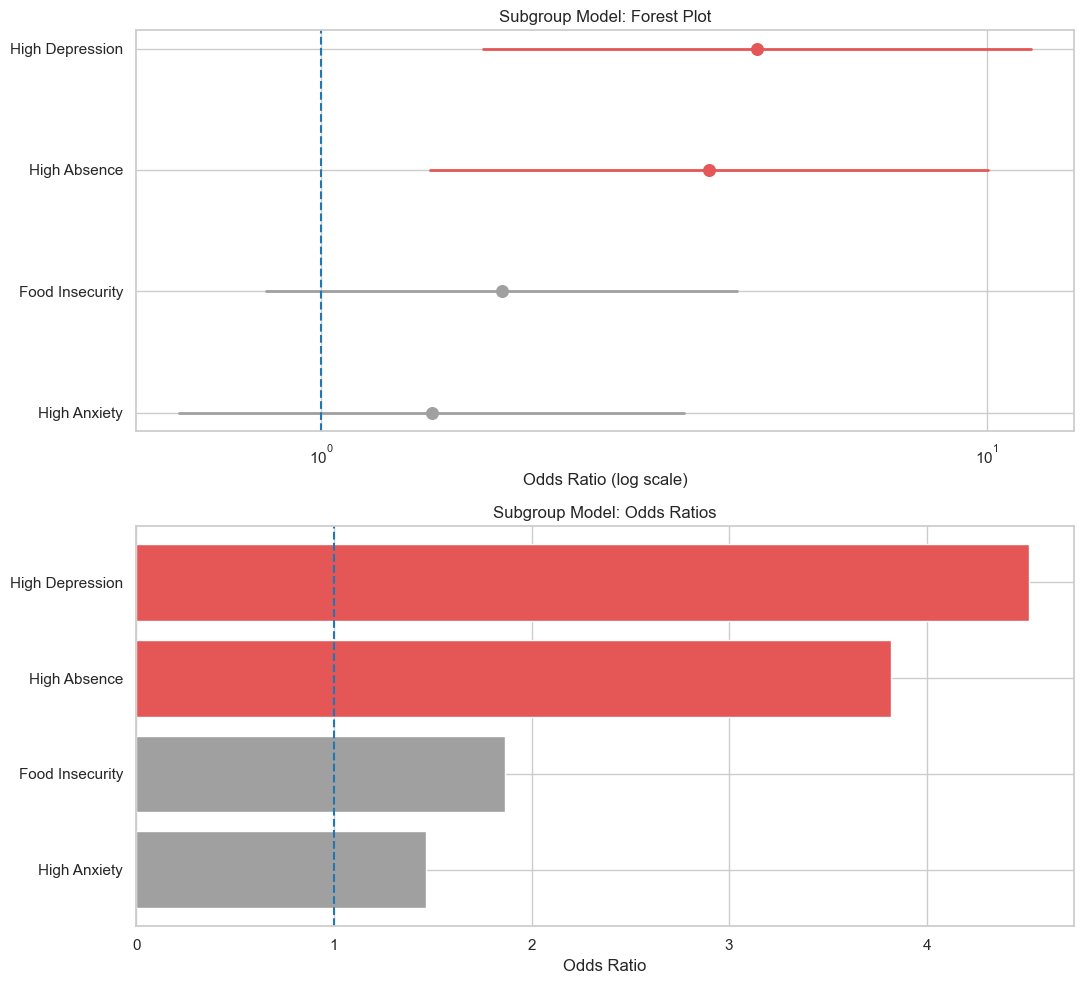

In [75]:
import statsmodels.api as sm
from IPython.display import display

# =========================================================
# Parsimonious Subgroup Logistic Regression
# Restricted to children with food allergy
# Outcome = poor_health (PHSTAT_C: 4/5 = 1)
# Main-result model with reduced predictors
# =========================================================

df = child_data.copy()


# Restrict to children with current food allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df = df[curfood == 1].copy()

# Outcome: poor health (PHSTAT_C 4/5)
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Psychosocial predictors
anx = pd.to_numeric(df["ANXFREQ_C"], errors="coerce")
df["high_anxiety"] = np.where(
    anx.isin([1, 2]), 1,
    np.where(anx.isin([3, 4, 5]), 0, np.nan)
)

dep = pd.to_numeric(df["DEPFREQ_C"], errors="coerce")
df["high_depression"] = np.where(
    dep.isin([1, 2]), 1,
    np.where(dep.isin([3, 4, 5]), 0, np.nan)
)

sch = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["high_absence"] = np.where(
    sch.between(18, 95), 1,
    np.where(sch.between(0, 17), 0, np.nan)
)

# Core SDOH predictors
# notcov = pd.to_numeric(df["NOTCOV_C"], errors="coerce")
# df["notcov_risk"] = np.where(notcov == 1, 1, np.where(notcov == 2, 0, np.nan))

fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

analysis_df_main = df[[
    "poor_health",
    "high_anxiety",
    "high_depression",
    "high_absence",
    "food_insecure"
]].dropna().copy()

for col in analysis_df_main.columns:
    analysis_df_main[col] = analysis_df_main[col].astype(int)

zero_variance_cols = [
    col for col in analysis_df_main.columns
    if col != "poor_health" and analysis_df_main[col].nunique() < 2
]
if zero_variance_cols:
    print("Dropped zero-variance predictors:", ", ".join(zero_variance_cols))
    analysis_df_main = analysis_df_main.drop(columns=zero_variance_cols)

print(f"Parsimonious model sample size: {len(analysis_df_main):,}")
print(f"Poor health = 1: {analysis_df_main['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df_main['poor_health'] == 0).sum():,}")

X = analysis_df_main.drop(columns=["poor_health"]).copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df_main["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

coef_df_main = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values
})

conf = logit_result.conf_int()
coef_df_main["ci_lower"] = np.exp(conf[0].values)
coef_df_main["ci_upper"] = np.exp(conf[1].values)
coef_df_main = coef_df_main[coef_df_main["variable"] != "const"].copy()
coef_df_main["significant"] = coef_df_main["p_value"] < 0.05
coef_df_main["effect_size"] = np.abs(np.log(coef_df_main["odds_ratio"]))

name_map = {
    "high_anxiety": "High Anxiety",
    "high_depression": "High Depression",
    "high_absence": "High Absence",
    "food_insecure": "Food Insecurity"
}
coef_df_main["label"] = coef_df_main["variable"].map(name_map).fillna(coef_df_main["variable"])

results_main = coef_df_main.sort_values(["p_value", "effect_size"], ascending=[True, False]).reset_index(drop=True)
sig_results = results_main[results_main["significant"]].copy()

print("\nParsimonious subgroup logistic regression results:")
display(results_main[["label", "odds_ratio", "ci_lower", "ci_upper", "p_value", "significant"]])

print("\nInterpretation:")
for row in sig_results.itertuples(index=False):
    if row.odds_ratio >= 1:
        direction_text = f"{row.odds_ratio:.2f} times higher odds"
    else:
        direction_text = f"{1 / row.odds_ratio:.2f} times lower odds"
    print(
        f"- {row.label} is significantly associated with poor health "
        f"(OR={row.odds_ratio:.2f}, 95% CI {row.ci_lower:.2f}-{row.ci_upper:.2f}, p={row.p_value:.3g}). "
        f"This corresponds to {direction_text}."
    )

print("- This main-result model is restricted to children with current food allergy.")
print("- The outcome is poor health, defined as PHSTAT_C in 4 or 5.")
print("- The predictor set is reduced to improve stability and interpretability.")

# -----------------------------------
# Visualization
# -----------------------------------
plot_df = results_main.copy()
plot_df["color"] = np.where(plot_df["significant"], "#E45756", "#A0A0A0")
plot_df = plot_df.iloc[::-1]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(11, 10))

# 1) Forest plot
for i, row in enumerate(plot_df.itertuples(index=False)):
    axes[0].plot([row.ci_lower, row.ci_upper], [i, i], color=row.color, linewidth=2)
    axes[0].scatter(row.odds_ratio, i, color=row.color, s=70, zorder=3)

axes[0].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[0].set_xscale("log")
axes[0].set_yticks(range(len(plot_df)))
axes[0].set_yticklabels(plot_df["label"])
axes[0].set_xlabel("Odds Ratio (log scale)")
axes[0].set_title("Subgroup Model: Forest Plot")

# 2) Bar chart
axes[1].barh(plot_df["label"], plot_df["odds_ratio"], color=plot_df["color"])
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Odds Ratio")
axes[1].set_title("Subgroup Model: Odds Ratios")

plt.tight_layout()
plt.show()


Sample size: 621
Poor health = 1: 40
Poor health = 0: 581

2x2 Table (counts):


Poor Health,0,1
Food Insecure,,
0,496,27
1,85,13



2x2 Table (row %):


Poor Health,0,1
Food Insecure,,
0,94.84,5.16
1,86.73,13.27



Crude OR from 2x2 table: 2.8096

Simple logistic regression results:


,variable,odds_ratio,ci_lower,ci_upper,p_value
1,food_insecure,2.809586,1.39449,5.660687,0.003848



Interpretation:
- Food insecurity is associated with poor health (OR=2.81, 95% CI 1.39-5.66, p=0.00385).
- This corresponds to 2.81 times higher odds of poor health.
- This is an unadjusted model restricted to children with current food allergy.


/var/folders/sc/_8qp44f14292wc07xsg6dkmr0000gn/T/ipykernel_57298/473167993.py:135: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


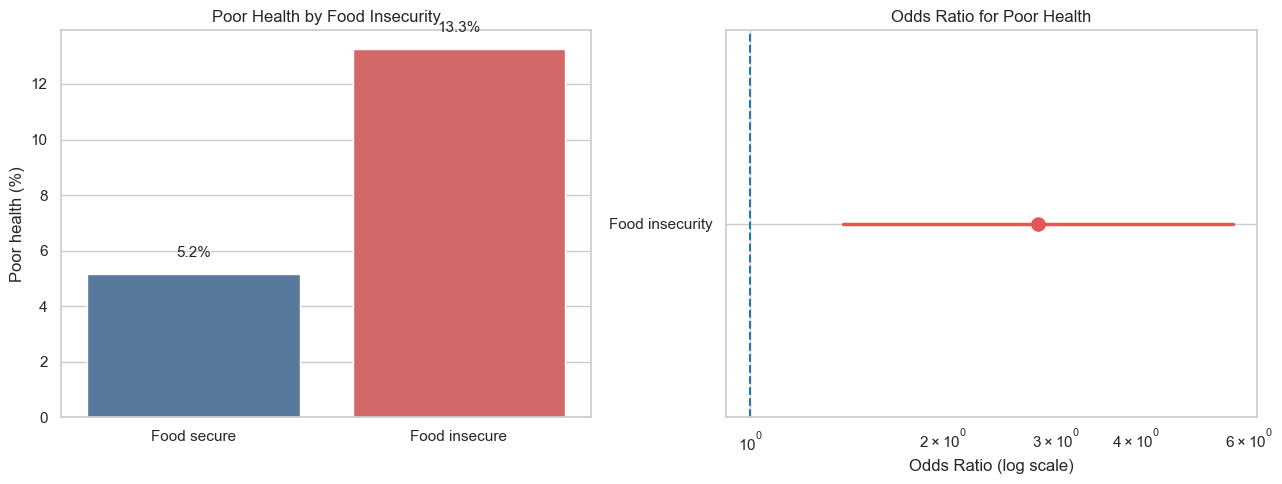

In [76]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# =========================================================
# Simple Logistic Regression + 2x2 Table + Graphs
# Restricted to children with current food allergy
# Outcome = poor_health
# Predictor = food_insecure only
# =========================================================

df = child_data.copy()

# Restrict to children with current food allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df = df[curfood == 1].copy()

# Outcome: poor health (4/5 = 1, 1/2/3 = 0)
ph = pd.to_numeric(df["PHSTAT_C"], errors="coerce")
df["poor_health"] = np.where(
    ph.isin([4, 5]), 1,
    np.where(ph.isin([1, 2, 3]), 0, np.nan)
)

# Predictor: food insecurity
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

# Analysis dataset
analysis_df = df[["poor_health", "food_insecure"]].dropna().copy()

for col in analysis_df.columns:
    analysis_df[col] = analysis_df[col].astype(int)

print(f"Sample size: {len(analysis_df):,}")
print(f"Poor health = 1: {analysis_df['poor_health'].sum():,}")
print(f"Poor health = 0: {(analysis_df['poor_health'] == 0).sum():,}")

# =========================================================
# 2x2 table
# =========================================================
table_2x2 = pd.crosstab(
    analysis_df["food_insecure"],
    analysis_df["poor_health"],
    rownames=["Food Insecure"],
    colnames=["Poor Health"],
    dropna=False
)

table_2x2 = table_2x2.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

print("\n2x2 Table (counts):")
display(table_2x2)

row_pct = table_2x2.div(table_2x2.sum(axis=1), axis=0) * 100
print("\n2x2 Table (row %):")
display(row_pct.round(2))

a = table_2x2.loc[1, 1]
b = table_2x2.loc[1, 0]
c = table_2x2.loc[0, 1]
d = table_2x2.loc[0, 0]

if b > 0 and c > 0:
    crude_or = (a * d) / (b * c)
    print(f"\nCrude OR from 2x2 table: {crude_or:.4f}")
else:
    crude_or = np.nan
    print("\nCrude OR from 2x2 table: cannot compute because of zero cell count.")

# =========================================================
# Logistic regression
# =========================================================
X = analysis_df[["food_insecure"]].copy()
X = sm.add_constant(X, has_constant="add")
y = analysis_df["poor_health"]

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False, maxiter=300)

conf = logit_result.conf_int()
results = pd.DataFrame({
    "variable": logit_result.params.index,
    "beta": logit_result.params.values,
    "odds_ratio": np.exp(logit_result.params.values),
    "p_value": logit_result.pvalues.values,
    "ci_lower": np.exp(conf[0].values),
    "ci_upper": np.exp(conf[1].values)
})

results = results[results["variable"] != "const"].copy()

print("\nSimple logistic regression results:")
display(results[["variable", "odds_ratio", "ci_lower", "ci_upper", "p_value"]])

row = results.iloc[0]
if row["odds_ratio"] >= 1:
    direction_text = f"{row['odds_ratio']:.2f} times higher odds"
else:
    direction_text = f"{1 / row['odds_ratio']:.2f} times lower odds"

print("\nInterpretation:")
print(
    f"- Food insecurity is associated with poor health "
    f"(OR={row['odds_ratio']:.2f}, 95% CI {row['ci_lower']:.2f}-{row['ci_upper']:.2f}, p={row['p_value']:.3g})."
)
print(f"- This corresponds to {direction_text} of poor health.")
print("- This is an unadjusted model restricted to children with current food allergy.")

# =========================================================
# Visualization
# =========================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1) Bar plot: percent with poor health by food insecurity
plot_bar = (
    analysis_df.groupby("food_insecure")["poor_health"]
    .mean()
    .reset_index()
)
plot_bar["poor_health_pct"] = plot_bar["poor_health"] * 100
plot_bar["group"] = plot_bar["food_insecure"].map({
    0: "Food secure",
    1: "Food insecure"
})

sns.barplot(
    data=plot_bar,
    x="group",
    y="poor_health_pct",
    palette=["#4C78A8", "#E45756"],
    ax=axes[0]
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Poor health (%)")
axes[0].set_title("Poor Health by Food Insecurity")

for i, val in enumerate(plot_bar["poor_health_pct"]):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center", va="bottom", fontsize=11)

# 2) Forest plot: odds ratio with 95% CI
or_val = row["odds_ratio"]
ci_low = row["ci_lower"]
ci_high = row["ci_upper"]
sig_color = "#E45756" if row["p_value"] < 0.05 else "#A0A0A0"

axes[1].plot([ci_low, ci_high], [0, 0], color=sig_color, linewidth=2.5)
axes[1].scatter(or_val, 0, color=sig_color, s=90, zorder=3)
axes[1].axvline(1, color="#1F77B4", linestyle="--", linewidth=1.5)

axes[1].set_xscale("log")
axes[1].set_yticks([0])
axes[1].set_yticklabels(["Food insecurity"])
axes[1].set_xlabel("Odds Ratio (log scale)")
axes[1].set_title("Odds Ratio for Poor Health")
axes[1].set_ylim(-0.8, 0.8)

plt.tight_layout()
plt.show()


School absence days (SCHDYMSSTC_C) by food allergy status, ages 5-17


,Group,N,Mean,SD
0,No Allergy,5622,3.75,5.57
1,Allergy,521,5.36,7.20


,Comparison,t statistic,df,p value,Mean difference
0,Allergy vs No Allergy,4.962,579.07,0.000001,1.61


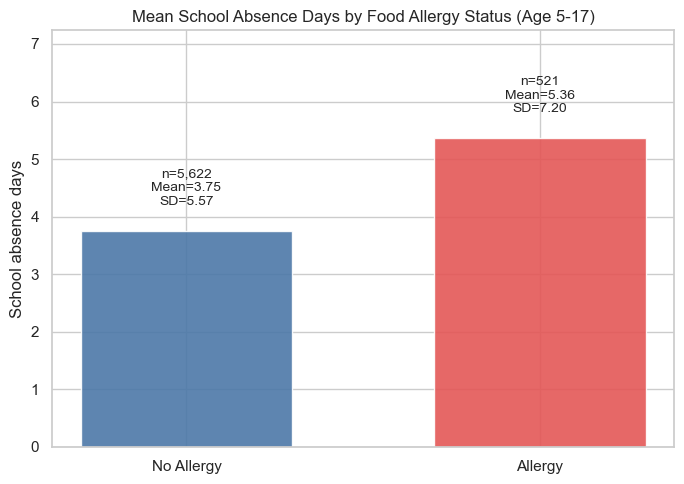

In [77]:
# School absence days <-> Food Allergy


import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# =========================================================
# School absence days (continuous) by food allergy status
# Age restricted to 5-17 years
# =========================================================

df = child_data.copy()

# 1) Restrict to ages 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# 2) Food allergy status: 1 = Allergy, 0 = No allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# 3) School absence days as a continuous variable
# Keep valid values only; exclude special/missing codes
absence = pd.to_numeric(df["SCHDYMSSTC_C"], errors="coerce")
df["school_absence_days"] = np.where(absence.between(0, 94), absence, np.nan)

# 4) Complete cases for analysis
analysis_df = df[["food_allergy", "school_absence_days"]].dropna().copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)

# 5) Split into groups
no_allergy = analysis_df.loc[analysis_df["food_allergy"] == 0, "school_absence_days"]
allergy = analysis_df.loc[analysis_df["food_allergy"] == 1, "school_absence_days"]

# 6) Summary table: N, mean, SD
summary_table = pd.DataFrame({
    "Group": ["No Allergy", "Allergy"],
    "N": [len(no_allergy), len(allergy)],
    "Mean": [no_allergy.mean(), allergy.mean()],
    "SD": [no_allergy.std(ddof=1), allergy.std(ddof=1)]
})
summary_table[["Mean", "SD"]] = summary_table[["Mean", "SD"]].round(2)

# 7) Welch t-test
t_stat, p_value = stats.ttest_ind(allergy, no_allergy, equal_var=False)

# Welch-Satterthwaite degrees of freedom
n1, n0 = len(allergy), len(no_allergy)
s1, s0 = allergy.var(ddof=1), no_allergy.var(ddof=1)
welch_df = (s1 / n1 + s0 / n0) ** 2 / (((s1 / n1) ** 2) / (n1 - 1) + ((s0 / n0) ** 2) / (n0 - 1))
mean_diff = allergy.mean() - no_allergy.mean()

ttest_table = pd.DataFrame({
    "Comparison": ["Allergy vs No Allergy"],
    "t statistic": [round(t_stat, 3)],
    "df": [round(welch_df, 2)],
    "p value": [round(p_value, 6)],
    "Mean difference": [round(mean_diff, 2)]
})

print("School absence days (SCHDYMSSTC_C) by food allergy status, ages 5-17")
display(summary_table)
display(ttest_table)

# 8) Visualization: mean only, with n/mean/SD labels
plot_df = summary_table.copy()
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
bars = plt.bar(
    plot_df["Group"],
    plot_df["Mean"],
    color=["#4C78A8", "#E45756"],
    width=0.6,
    alpha=0.9
)

for i, row in plot_df.iterrows():
    plt.text(
        i,
        row["Mean"] + 0.4,
        f"n={int(row['N']):,}\nMean={row['Mean']:.2f}\nSD={row['SD']:.2f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title("Mean School Absence Days by Food Allergy Status (Age 5-17)")
plt.ylabel("School absence days")
plt.xlabel("")
plt.ylim(0, max(plot_df["Mean"].max() * 1.35, 5))
plt.tight_layout()
plt.show()


In [78]:
# Food insecurity prevalence by food allergy status

from scipy.stats import chi2_contingency
from IPython.display import display

df = child_data.copy()

# Restrict to ages 5-17
age = pd.to_numeric(df["AGEP_C"], errors="coerce")
df = df[age.between(5, 17)].copy()

# Food allergy status: 1 = Allergy, 0 = No allergy
curfood = pd.to_numeric(df["CURFOOD_C"], errors="coerce")
df["food_allergy"] = np.where(curfood == 1, 1, np.where(curfood == 2, 0, np.nan))

# Food insecurity: 3/4 = Low/Very Low, 1/2 = High/Marginal
fd = pd.to_numeric(df["FDSCAT4_C"], errors="coerce")
df["food_insecure"] = np.where(
    fd.isin([3, 4]), 1,
    np.where(fd.isin([1, 2]), 0, np.nan)
)

analysis_df = df.dropna(subset=["food_allergy", "food_insecure"]).copy()
analysis_df["food_allergy"] = analysis_df["food_allergy"].astype(int)
analysis_df["food_insecure"] = analysis_df["food_insecure"].astype(int)

ct = pd.crosstab(analysis_df["food_allergy"], analysis_df["food_insecure"]).reindex(
    index=[0, 1], columns=[0, 1], fill_value=0
)

chi2, p_value, dof, expected = chi2_contingency(ct)

summary_df = pd.DataFrame({
    "Group": ["No Allergy", "Allergy"],
    "High/Marginal N": [int(ct.loc[0, 0]), int(ct.loc[1, 0])],
    "Low/Very Low N": [int(ct.loc[0, 1]), int(ct.loc[1, 1])],
    "Total N": [int(ct.loc[0].sum()), int(ct.loc[1].sum())],
    "Low/Very Low %": [
        round(ct.loc[0, 1] / ct.loc[0].sum() * 100, 2),
        round(ct.loc[1, 1] / ct.loc[1].sum() * 100, 2)
    ]
})

chi_result = pd.DataFrame({
    "chi_square": [round(chi2, 4)],
    "p_value": [round(p_value, 6)],
    "degrees_of_freedom": [dof],
    "significant": [p_value < 0.05]
})

print("Food insecurity prevalence by food allergy status (ages 5-17)")
display(summary_df)

print("Chi-square test result:")
display(chi_result)

print(
    f"Children with food allergies had a low/very low food security prevalence of "
    f"{summary_df.loc[1, 'Low/Very Low %']:.2f}% compared with {summary_df.loc[0, 'Low/Very Low %']:.2f}% "
    f"among children without food allergies (p = {p_value:.6f})."
)


Food insecurity prevalence by food allergy status (ages 5-17)


,Group,High/Marginal N,Low/Very Low N,Total N,Low/Very Low %
0,No Allergy,4922,682,5604,12.17
1,Allergy,433,84,517,16.25


Chi-square test result:


,chi_square,p_value,degrees_of_freedom,significant
0,6.8211,0.009009,1,True


Children with food allergies had a low/very low food security prevalence of 16.25% compared with 12.17% among children without food allergies (p = 0.009009).
